# C00 · Punto de partida del bloque C: aprendizaje profundo bajo el protocolo común

**Para quién.** Para ti, Cesar: bloque C, objetivo específico 3 (OE3). También le sirve a Jonathan para ver cómo se monta un diagnóstico por ventanas sin fuga de datos.

**Qué vas a aprender.**
- Por qué un autoencoder es el primo no lineal del SPE del PCA, y qué obliga eso a hacer con su umbral.
- A entrenar un autoencoder de detección solo con operación normal, con parada temprana sobre normales de validación, y a calibrar su umbral con normales reservados.
- A evaluarlo en los 21 fallos junto al PCA-SPE con exactamente los mismos datos, con FAR, FDR y retardo, y con los fallos 3, 9 y 15 aparte.
- A medir, con cifras que salen de celdas, las dos trampas de protocolo que más inflan la literatura de aprendizaje profundo sobre el TEP: calibrar el umbral con los datos de entrenamiento y elegirlo mirando la prueba. Es el núcleo de tu «atribuir las diferencias a los componentes del protocolo».
- A pasar a Rieth con varias simulaciones, intervalos de confianza y contraste pareado.
- A montar un diagnóstico con ventanas temporales que no cruzan simulaciones y a medir bien el F1 por clase y el macro-F1.
- Qué hay que replicar de Lyu et al. (2026) y qué queda por verificar.

**Prerrequisito.** Haber recorrido `01_primeros_pasos.ipynb`. Aquí se da por sabido qué son T², SPE, FAR, FDR, retardo, `detected_at_chance` y la calibración con datos reservados. El `03_arranque_deeplearning.ipynb` es la versión anterior de este cuaderno; sus defectos conocidos están en la última sección.

**Cómo recorrerlo.** En orden, celda por celda (Shift+Enter) y sin cambiar nada la primera vez. Tras cada resultado relevante hay una celda **Cómo leerlo** que te dice dónde mirar en la salida. Ninguna cifra de resultado está escrita a mano en el texto, así que la lectura vale aunque cambien los números. Las celdas **Verifícalo tú** son ejercicios cortos con la solución comentada: intenta primero, y después quita los `# ` de la solución y ejecútala. Al final, **Te toca** reúne las celdas `TODO` que son tu contribución.

**Tiempo estimado.** Del orden de uno o dos minutos de ejecución en un portátil sin GPU (la última celda imprime cuánto tardó en tu equipo) y un par de horas de lectura con calma. En Rieth se usa un subconjunto de desarrollo de `datos.runs_desarrollo` simulaciones (del yaml), no las 500.

**Qué necesitas.**
- El paquete `tfmfdd` y el TEP clásico en `data/tep_classic/`. Hoy no hay una etiqueta que sirva (hallazgo B1 de la revisión del 27/09): `v0.2` no está en GitHub y `v0.1` instala el paquete del 17/09, sin `convert_rieth` y con el `compare_methods` antiguo. Hasta que exista la `v0.3`, ejecuta el cuaderno dentro del repositorio `tfm-fdd-core` con `pip install -e .`. El cuaderno lee `configs/baseline.yaml` de la raíz del repositorio: ese fichero no viaja con el paquete.
- Opcional: PyTorch para CPU (`python -m pip install torch --index-url https://download.pytorch.org/whl/cpu`). Sin él, el cuaderno usa redes de scikit-learn y corre igual.
- Opcional: los Parquet de Rieth. Pídeselos a Pablo y comprueba el SHA-256; sin ellos, las partes de Rieth se saltan con un mensaje.

> Escrito el 27 de septiembre de 2026 sobre la rama `revision-2026-09` del paquete, todavía sin etiqueta. Lo que el paquete hace mal hoy, y cómo lo esquiva este cuaderno, está en la última sección. Revisado el mismo día contra las reglas de medida (`docs/reglas_de_medida.md`); el estado de los cuadernos de arranque está en `docs/estado_baselines_2026-09-27.md`.

## Las reglas de medida

Son las once reglas del protocolo común. Valen igual para los tres bloques; si tu cifra y la de Pablo o Jonathan no se miden igual, no se pueden comparar. Cada una dice qué función del paquete la implementa y qué fuga o qué inflado evita.

1. **Partición por simulación, nunca por muestra** (`data.split_runs`). Las muestras de una simulación están autocorrelacionadas: si una parte cae en entrenamiento y otra en prueba, el modelo aprende a reconocer la trayectoria en vez del fallo y la cifra sale inflada. En el TEP clásico, entrenamiento (`dXX.dat`) y prueba (`dXX_te.dat`) ya son simulaciones distintas. En Rieth, `split_runs` reparte los identificadores una sola vez y con los mismos ids para todas las clases, porque la simulación normal r y la de fallo r comparten semilla: son la misma trayectoria hasta que entra el fallo.
2. **Escalado ajustado solo con los datos de ajuste** (`preprocessing.Scaler`). Si la media y la desviación se calculan con la prueba, el modelo ya ha visto la prueba; además, un desplazamiento de media que es justo el fallo quedaría absorbido en parte por el escalado.
3. **Umbrales calibrados con normales reservados que el modelo no vio** (`limits.limit_empirical`, `limits.limit_kde`, `PCAMonitor.fit(..., X_cal=...)`). La red minimiza el error sobre sus datos de entrenamiento, así que ahí el error es artificialmente pequeño: un umbral calibrado ahí queda bajo y dispara falsas alarmas sobre datos nuevos. La fracción reservada es `particion.calibracion_limites` del yaml; en el clásico se corta en el tiempo y en Rieth se usan simulaciones normales distintas. Elegir el umbral mirando la prueba (por ejemplo, el que maximiza el F1) es fuga de datos: la sección 5 lo mide. Cuatro matices de la verificación del 27/09: `PCAMonitor.fit` sin `X_cal` calibra en muestra sin avisar, y su `variance` por defecto no es la del yaml (pásala siempre desde el yaml); el límite F del T² no usa `X_cal`; el del SPE por Jackson sale de los autovalores de `X_fit`, así que en la práctica es una calibración en muestra; y el percentil empírico con pocas muestras reservadas da, en promedio, algo más de FAR que la nominal. Además, «no mirar la prueba» incluye no reutilizar para el resultado confirmatorio las simulaciones de Rieth ya miradas en desarrollo (lista en `docs/reglas_de_medida.md`).
4. **Detección con `metrics.evaluate_run`.** La tasa de falsas alarmas (FAR, *false alarm rate*) se mide sobre `stat[:onset]` y la tasa de detección (FDR, *fault detection rate*) sobre `stat[onset:]`; en los ficheros de prueba el fallo entra tras la muestra 160 (`data.FAULT_ONSET_TEST`). El retardo de detección (*detection delay*) es la primera alarma de la primera racha de k alarmas seguidas (`protocolo.k_alarmas`). Si `detected_at_chance` es `True` (FDR < 0,10), ese retardo **no se interpreta**: es una racha que aparece por azar. Los resúmenes se hacen a mano, porque `metrics.summary` hoy promedia también esos retardos (defecto I1). Y la FDR se lee siempre al lado de la FAR: `detected_at_chance` solo mira si la FDR es baja, así que un detector que alarma casi siempre pasa el filtro. En Rieth, la FAR se mide en `test_fault00` (sección 6).
5. **Diagnóstico: F1 por clase sobre todo el conjunto de prueba, y macro-F1** (`sklearn.metrics.precision_recall_fscore_support` y `f1_score(..., average=None)`). La precisión de una clase necesita las muestras de las demás clases que el modelo le atribuyó por error. Si calculas el F1 solo con las muestras de una clase, no hay falsos positivos posibles y lo que sale es 2r/(1+r), no un F1 (defecto B3): infla justo las clases difíciles.
6. **Dónde entra el fallo en entrenamiento.** TEP clásico: los `dXX.dat` (480 filas) tienen el fallo activo desde la fila 0 y se usan enteros; `data.fault_onset("train", "classic")` devuelve `None`. No uses `data.FAULT_ONSET_TRAIN_CLASSIC`: vale 20 y es un dato falso (defecto B2). Rieth: el fallo entra tras la muestra 20 en entrenamiento y tras la 160 en prueba (`data.fault_onset(split, "rieth")`), comprobado con los datos; en los ficheros de fallo se descartan las filas anteriores, porque son copia exacta de la simulación normal con el mismo id. Ojo: el inicio nominal no siempre es el efectivo. En algunos fallos la trayectoria sigue idéntica a su gemela varias muestras después, y descartar solo `sample <= onset` deja unas pocas filas con etiqueta de fallo que son copia de la clase 0; la sección 6 lo mide.
7. **Fallos 3, 9 y 15 siempre aparte** (`metrics.HARD_FAULTS`). Su firma apenas se separa del ruido; promediarlos con el resto esconde el único sitio donde los métodos podrían diferenciarse. Lyu et al. (2026) los excluyen, y ese es uno de los huecos que cubre tu OE3.
8. **Contrastes: Wilcoxon pareado con Holm por fallo y alfa de contraste 0,05, declarado antes de ver resultados** (`stats.compare_methods`, que usa `zero_method="zsplit"`). Se reporta la diferencia (la mediana de las diferencias por simulación), no solo el p. Con una sola simulación (clásico) no hay contraste posible y los números son orientativos. Hoy `compare_methods` hace todos contra todos; el análisis principal contra el baseline llega con la v0.3.
9. **Semillas y configuración desde `configs/baseline.yaml`**: `protocolo.semilla`, `protocolo.alpha` (el nivel de confianza del límite, que no es el alfa 0,05 de los contrastes), `pca.variance`, `particion.calibracion_limites` y `datos.runs_desarrollo`. Nada que esté en el yaml se fija a mano en una celda: si el protocolo cambia, cambia en un solo sitio para los tres.
10. **Ningún número de resultado escrito a mano en el texto.** Las interpretaciones remiten a la salida de la celda. Así el texto no se desfasa cuando cambian los datos, la semilla o la librería; ya pasó que cifras de dos configuraciones distintas acabaran citadas como la misma. Los hechos de los datos (52 variables, 160, 480, 500, 960) sí se escriben.
11. **Formato común de resultados**: una fila por (`method`, `faultNumber`, `simulationRun`). Detección: las columnas de `evaluate_run`. Diagnóstico: el recall por (fallo, simulación), y la precisión y el F1 por clase calculados sobre el conjunto de prueba. Mientras sea una prueba de humo se guarda en `results/raw/` (ignorado por git), no en `results/summary/`.

## 0. Preparar el entorno → `configs/baseline.yaml`

La primera celda sube a la raíz del repositorio si hace falta (igual que el 01), lee el protocolo común y decide dónde están los datos de Rieth. La segunda importa el paquete, fija la semilla y comprueba si hay PyTorch. Fíjate en que ningún valor del protocolo se escribe a mano: todos salen del yaml (regla 9).

In [1]:
# Los cuadernos viven en notebooks/ y los datos en data/: si hace falta, sube a la raíz.
import os
import time
from pathlib import Path
import yaml
if not Path("data").exists() and Path("../data").exists():
    os.chdir("..")
print("Directorio de trabajo:", os.getcwd())
T_INICIO = time.time()

# El protocolo común: una sola fuente para los tres bloques (regla 9).
with open("configs/baseline.yaml", encoding="utf-8") as fh:
    cfg = yaml.safe_load(fh)
SEMILLA = cfg["protocolo"]["semilla"]
NIVEL = cfg["protocolo"]["alpha"]            # nivel de confianza del límite; NO es el alfa de los contrastes
K = cfg["protocolo"]["k_alarmas"]
MINUTOS = cfg["protocolo"]["sample_minutes"]
F_CAL = cfg["particion"]["calibracion_limites"]
FRACCIONES = (cfg["particion"]["fraccion_ajuste"], cfg["particion"]["fraccion_validacion"],
              cfg["particion"]["fraccion_prueba"])
N_DESARROLLO = cfg["datos"]["runs_desarrollo"]
ALPHA_CONTRASTES = 0.05   # aún no está en el yaml (llega con la v0.3); se declara aquí, antes de ver nada
print(f"Semilla {SEMILLA} | nivel de confianza del límite {NIVEL} | k = {K} | reserva para calibrar {F_CAL}")
print(f"Fracciones por simulación (ajuste, validación, prueba): {FRACCIONES} | desarrollo en Rieth: {N_DESARROLLO}")

# ¿Dónde están los Parquet de Rieth? Prioridad: variable de entorno, data/tep_rieth, ~/datos_tfm/tep_rieth.
def _tiene_parquet(carpeta):
    return carpeta.is_dir() and any(carpeta.glob("*.parquet"))

if os.environ.get("TFM_RIETH_DIR"):
    RIETH_DIR, ORIGEN_RIETH = Path(os.environ["TFM_RIETH_DIR"]), "variable de entorno TFM_RIETH_DIR"
elif _tiene_parquet(Path("data/tep_rieth")):
    RIETH_DIR, ORIGEN_RIETH = Path("data/tep_rieth"), "data/tep_rieth del repositorio"
else:
    RIETH_DIR, ORIGEN_RIETH = Path.home() / "datos_tfm" / "tep_rieth", "carpeta por defecto ~/datos_tfm/tep_rieth"
HAY_RIETH = _tiene_parquet(RIETH_DIR)
MENSAJE_SIN_RIETH = (
    "No hay Parquet de Rieth: esta parte se salta. Lo mejor es pedirle los Parquet a Pablo y comprobar\n"
    "su SHA-256 (convertir el fichero de prueba con fallos puede agotar la memoria de un portátil de 16 GB).\n"
    "Si aun así quieres convertir, hazlo de uno en uno y de menor a mayor, con el navegador cerrado y\n"
    "preferiblemente fuera de OneDrive o Google Drive:\n"
    "  python -m tfmfdd.convert_rieth --origen <carpeta .RData> --destino ~/datos_tfm/tep_rieth --solo <fichero>\n"
    "con <fichero> = faultfree_training, luego faultfree_testing, faulty_training y faulty_testing.\n"
    "Si los dejas en otra carpeta, define la variable de entorno TFM_RIETH_DIR antes de abrir el cuaderno."
)
print(f"RIETH_DIR = {RIETH_DIR}  ({ORIGEN_RIETH}) | ¿hay Parquet? {HAY_RIETH}")
if not HAY_RIETH:
    print(MENSAJE_SIN_RIETH)

Directorio de trabajo: C:\Users\pabdu\OneDrive\Documentos\Universidades\UNIR\TFM\tfm-fdd-core\tfm-fdd-core
Semilla 42 | nivel de confianza del límite 0.99 | k = 3 | reserva para calibrar 0.3
Fracciones por simulación (ajuste, validación, prueba): (0.6, 0.2, 0.2) | desarrollo en Rieth: 20
RIETH_DIR = C:\Users\pabdu\datos_tfm\tep_rieth  (carpeta por defecto ~/datos_tfm/tep_rieth) | ¿hay Parquet? True


In [2]:
import copy, importlib.util, json, platform, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import confusion_matrix, f1_score, precision_recall_fscore_support

import tfmfdd
from tfmfdd import data, limits, metrics, plots, stats
from tfmfdd.pca import PCAMonitor
from tfmfdd.preprocessing import Scaler

plots.use_style()
pd.set_option("display.max_columns", 30)          # que las tablas por clase se vean enteras
DIFICILES = tuple(metrics.HARD_FAULTS)
assert set(DIFICILES) == set(cfg["fallos_dificiles"])   # el paquete y el yaml dicen lo mismo
np.random.seed(SEMILLA)
print("Fallos difíciles, siempre aparte:", DIFICILES)

# PyTorch es opcional. Pon USAR_TORCH en False para forzar la alternativa de scikit-learn.
USAR_TORCH = True
TORCH_INSTALADO = importlib.util.find_spec("torch") is not None
USAR_TORCH = USAR_TORCH and TORCH_INSTALADO
if USAR_TORCH:
    import torch
    from torch import nn
    torch.manual_seed(SEMILLA)
    torch.set_num_threads(min(4, os.cpu_count() or 1))   # redes pequeñas: pocos hilos bastan y no acaparan el equipo
    print("Camino PyTorch, versión", torch.__version__, "| hilos:", torch.get_num_threads())
else:
    from sklearn.neural_network import MLPClassifier, MLPRegressor
    print("Camino scikit-learn" + ("" if TORCH_INSTALADO else " (PyTorch no está instalado)"))

Fallos difíciles, siempre aparte: (3, 9, 15)


Camino PyTorch, versión 2.14.0+cpu | hilos: 4


## 1. El autoencoder, primo no lineal del SPE → `pca.py`

En el 01 (sección 4) viste que el SPE es el tamaño del residuo, ‖z − ẑ‖², donde ẑ es la observación estandarizada **comprimida** a las componentes retenidas y **descomprimida** otra vez a 52 variables: ẑ = (z P) Pᵀ. Léelo como si fuera una red: un codificador lineal z ↦ t = z P (de 52 a unas pocas dimensiones), un decodificador lineal t ↦ t Pᵀ (de vuelta a 52) y el SPE como error de reconstrucción (*reconstruction error*). El PCA es un autoencoder lineal cuyos pesos no se entrenan por descenso de gradiente: salen de los autovectores.

Un autoencoder (una red que aprende a reproducir su entrada pasando por un cuello de botella) cambia esas dos matrices por funciones no lineales f y g, y mide e = ‖z − g(f(z))‖². El motivo de ingeniería: en un reactor las relaciones entre sensores no son rectas en todo el rango de operación (la velocidad de reacción crece de forma exponencial con la temperatura, las válvulas tienen curvas características), y una superficie curva de operación normal se describe con menos dimensiones si el modelo puede curvarse.

Lo que esto implica para el protocolo, que es lo único importante de esta sección:
- **Todo lo que el 01 dice del SPE vale para el error del autoencoder.** El error sobre los datos de entrenamiento es artificialmente pequeño, así que el umbral (*threshold*) se calibra con normales reservados.
- **No hay límite paramétrico.** Para el SPE existen Box y Jackson–Mudholkar (y el de Jackson no protege de nada: sale de los autovalores de `X_fit`, así que es una calibración en muestra implícita, hallazgo DIS-6 de la verificación del 27/09); para el autoencoder solo quedan los límites calibrados con datos (`limit_empirical`, `limit_kde`), que son justo los que sufren el sesgo de calibrar en muestra.
- **Muchos más parámetros**: más capacidad de memorizar el entrenamiento y más distancia entre el error de entrenamiento y el de datos nuevos.
- **El entrenamiento es iterativo**: hay que decidir cuándo parar, y esa decisión necesita su propio bloque de datos normales, distinto del de calibración y, por supuesto, de la prueba.

La celda siguiente comprueba la primera frase con números: el SPE del PCA y el error de reconstrucción del autoencoder lineal (P, Pᵀ) son el mismo vector.

In [3]:
# El SPE del PCA ES un error de reconstrucción. Aquí no se evalúa nada: solo se comprueba una
# identidad algebraica, así que da igual con qué datos normales se ajuste.
X_normal = data.values(data.load_classic(0, "train"))       # d00.dat: 500 muestras normales
pca_demo = PCAMonitor(variance=cfg["pca"]["variance"], alpha=NIVEL).fit(X_normal)

Z = pca_demo.scaler_.transform(X_normal)                     # estandarizar (preprocessing.Scaler)
P = pca_demo.loadings_                                       # (52, a): pesos del "codificador"
Z_rec = (Z @ P) @ P.T                                        # codificar y decodificar
error_lineal = ((Z - Z_rec) ** 2).sum(axis=1)                # error de reconstrucción por muestra
_, spe = pca_demo.score(X_normal)

print("Cuello de botella del autoencoder lineal:", P.shape[1], "neuronas para", P.shape[0], "variables")
print("¿Error de reconstrucción lineal = SPE en todas las muestras?", np.allclose(error_lineal, spe))

Cuello de botella del autoencoder lineal: 27 neuronas para 52 variables
¿Error de reconstrucción lineal = SPE en todas las muestras? True


C:\Users\pabdu\OneDrive\Documentos\Universidades\UNIR\TFM\tfm-fdd-core\tfm-fdd-core\tfmfdd\data.py:132: UserWarning: d00.dat: matriz transpuesta (52, 500), se corrige a (500, 52). Es el caso conocido de d00.dat.
  arr = _as_samples_by_vars(np.loadtxt(path), path.name)


### Verifícalo tú

Como PᵀP = I, la energía de cada observación se reparte sin pérdidas entre lo que el codificador guarda y lo que el decodificador no recupera: ‖z‖² = ‖t‖² + SPE. Compruébalo con `Z`, `P` y `spe` (pista: t = Z P). Después piensa por qué no se cumple lo mismo en un autoencoder no lineal.

In [4]:
# Verifícalo tú: ‖z‖² = ‖t‖² + SPE en el autoencoder lineal.
# Solución (quita los '# ' de las líneas de abajo y ejecuta):
# t = Z @ P                                              # lo que guarda el codificador
# energia = (Z ** 2).sum(axis=1)
# print("¿‖z‖² = ‖t‖² + SPE?", np.allclose(energia, (t ** 2).sum(axis=1) + spe))
# # En uno no lineal, g(f(z)) no es una proyección ortogonal y la energía no se reparte así:
# # por eso el error del autoencoder no tiene una distribución de referencia como la de Box.

## 2. Datos y partición → `data.py` y `preprocessing.py`

**TEP clásico.** Para detectar, el modelo solo ve operación normal: `d00.dat`, 500 muestras de una sola simulación. Se parte en tres bloques **consecutivos en el tiempo**, cada uno con un único trabajo:

| Bloque | Para qué | De dónde sale su tamaño |
|---|---|---|
| `Z_tr` | Entrenar los pesos de la red | lo que queda de `X_fit` |
| `Z_es` | Decidir cuándo parar (parada temprana, *early stopping*) | `particion.fraccion_validacion` de `X_fit` |
| `Z_cal` | Calibrar el umbral | `particion.calibracion_limites` del total (es `X_cal`) |

El PCA usa `X_fit` entero (los dos primeros bloques) para ajustarse, porque no necesita decidir cuándo parar, y `X_cal` para su límite: los dos detectores gastan el mismo presupuesto de datos normales. El escalador se ajusta con `X_fit` (regla 2), igual que el que `PCAMonitor` lleva dentro.

El corte es temporal y no aleatorio por lo mismo que en el 01 (sección 7): si barajas antes de cortar, muestras vecinas, casi idénticas por la autocorrelación, caen a los dos lados y la calibración vuelve a parecerse a una evaluación en muestra.

La prueba son los 22 ficheros `dXX_te.dat` (960 muestras; en los de fallo, 160 normales y el fallo desde la muestra 161). Son simulaciones distintas de `d00.dat`, así que la regla 1 se cumple sola.

**Rieth (sección 6).** Allí los tres papeles son **simulaciones distintas**: unas para entrenar, otras para parar y otras para calibrar, y la prueba sale de los ficheros de prueba, que no comparten semillas con los de entrenamiento. Es la versión limpia de este mismo esquema: con una sola simulación no se puede separar el sobreajuste de la deriva temporal (hallazgo I5 de la revisión); con muchas, sí.

                    bloque muestras   n
           Z_tr (entrenar)    1-280 280
    Z_es (parada temprana)  281-350  70
Z_cal (calibrar el umbral)  351-500 150


Prueba: 22 ficheros de (960, 52); el fallo entra tras la muestra 160
Autocorrelación de orden 1 de xmeas_7: 0.94


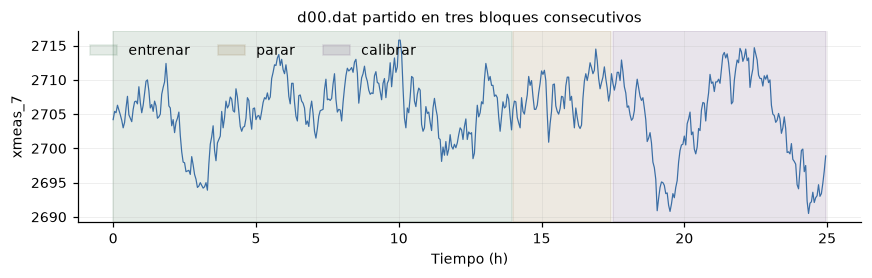

In [5]:
n = len(X_normal)
corte_cal = int(round(n * (1 - F_CAL)))              # el tramo final (calibracion_limites) se reserva
X_fit, X_cal = X_normal[:corte_cal], X_normal[corte_cal:]
n_es = int(round(len(X_fit) * FRACCIONES[1]))       # el último tramo de X_fit decide cuándo parar

escalador = Scaler().fit(X_fit)                      # SOLO con el ajuste (regla 2)
Z_fit, Z_cal = escalador.transform(X_fit), escalador.transform(X_cal)
Z_tr, Z_es = Z_fit[:-n_es], Z_fit[-n_es:]

bloques = pd.DataFrame({
    "bloque": ["Z_tr (entrenar)", "Z_es (parada temprana)", "Z_cal (calibrar el umbral)"],
    "muestras": [f"1-{len(Z_tr)}", f"{len(Z_tr) + 1}-{len(Z_fit)}", f"{len(Z_fit) + 1}-{n}"],
    "n": [len(Z_tr), len(Z_es), len(Z_cal)],
})
print(bloques.to_string(index=False))

# La prueba: los 22 ficheros dXX_te.dat, cargados una sola vez (22 x 960 x 52, pocos MB).
ONSET = data.FAULT_ONSET_TEST                         # 160
PRUEBA_CLASICO = {f: data.values(data.load_classic(f, "test")) for f in range(22)}
print(f"Prueba: {len(PRUEBA_CLASICO)} ficheros de {PRUEBA_CLASICO[1].shape}; el fallo entra tras la muestra {ONSET}")

# ¿Ruido blanco o inercia? Autocorrelación de orden 1 de la presión del reactor en d00.dat.
presion = X_normal[:, data.VAR_NAMES.index("xmeas_7")]
x = presion - presion.mean()
print("Autocorrelación de orden 1 de xmeas_7:", round(float((x[:-1] * x[1:]).sum() / (x ** 2).sum()), 3))

fig, ax = plt.subplots(figsize=(8, 2.6))
t_h = np.arange(n) * MINUTOS / 60
ax.plot(t_h, presion, color=plots.COLORS["normal"], lw=0.8)
tramos = [(0, len(Z_tr), "entrenar"), (len(Z_tr), len(Z_fit), "parar"), (len(Z_fit), n, "calibrar")]
for (ini, fin, nombre), color in zip(tramos, [plots.COLORS["alt1"], plots.COLORS["alt2"], plots.COLORS["alt3"]]):
    ax.axvspan(t_h[ini], t_h[fin - 1], color=color, alpha=0.15, label=nombre)
ax.set_xlabel("Tiempo (h)"); ax.set_ylabel("xmeas_7"); ax.legend(ncols=3, loc="upper left")
ax.set_title("d00.dat partido en tres bloques consecutivos")
plt.tight_layout()

### Cómo leerlo

Fíjate en la tabla: los tres bloques son consecutivos y no se solapan. La autocorrelación de orden 1 que imprime la celda mide cuánto se parece cada muestra a la anterior: cerca de 1 es mucha inercia y cerca de 0, ruido blanco. Si sale alta, es la razón concreta de que el corte sea temporal. En la figura, fíjate además en si el nivel de la señal en el bloque de calibrar se parece al de los otros dos: si el proceso deriva, el umbral absorbe esa deriva, y con una sola simulación no hay forma de distinguirla del sobreajuste. Por eso los resultados que valen salen de Rieth.

## 3. Autoencoder de detección, entrenado solo con normales → PyTorch o scikit-learn

La red es un perceptrón multicapa simétrico, 52 → 32 → 16 → 32 → 52, con activación tanh y salida lineal, entrenado con Adam para minimizar el error cuadrático medio de reconstrucción. Es pequeña a propósito: este cuaderno enseña el protocolo, no la arquitectura (la tuya va en *Te toca*). Con PyTorch la red se escribe a mano; sin PyTorch se usa `MLPRegressor` de scikit-learn con la misma arquitectura y el mismo bucle de parada temprana. Los hiperparámetros están en `HP_AE` y **no se han ajustado**: si los ajustas, que sea con datos de validación, nunca con la prueba. No están en el yaml porque no son del protocolo, son de tu modelo; declara los tuyos en tu repositorio antes de mirar la prueba.

**Parada temprana.** Tras cada época (*epoch*, una pasada completa por `Z_tr` en lotes o *batches*), se mide el error medio en `Z_es`, se guarda la mejor versión de los pesos y se para cuando pasan `paciencia` épocas sin una mejora relativa de al menos `mejora_min`. Dos prohibiciones:
- **Nunca con la prueba.** Elegir la época mirando la prueba es elegir el modelo con la respuesta delante: fuga de datos (*data leakage*).
- **Tampoco con `Z_cal`.** El bloque de calibración tiene que llegar virgen al umbral: si influyó en cuándo parar, el error sobre él sale optimista y el umbral, bajo. Es una fuga más sutil que las otras; la mides tú en el *Verifícalo tú* de esta sección.

In [6]:
# Hiperparámetros del autoencoder de este cuaderno: declarados, no ajustados.
HP_AE = {"capas": (32, 16), "lr": 1e-3, "lote": 32, "epocas_max": 400, "paciencia": 25,
         "mejora_min": 1e-3}   # mejora relativa mínima para contar como mejora (0,1 %)

def _capas_simetricas(capas):
    """(32, 16) -> (32, 16, 32): el decodificador es el espejo del codificador."""
    return tuple(capas) + tuple(capas[-2::-1])

if USAR_TORCH:
    def construir_ae(n_vars, capas):
        bloques_red, previo = [], n_vars
        for h in _capas_simetricas(capas):
            bloques_red += [nn.Linear(previo, h), nn.Tanh()]
            previo = h
        bloques_red.append(nn.Linear(previo, n_vars))      # salida lineal: reconstruye z
        return nn.Sequential(*bloques_red)

    def entrenar_autoencoder(Z_tr, Z_es, hp):
        """Entrena con Z_tr; parada temprana con Z_es (normales). Devuelve la red y la curva de validación."""
        torch.manual_seed(SEMILLA)
        red = construir_ae(Z_tr.shape[1], hp["capas"])
        opt = torch.optim.Adam(red.parameters(), lr=hp["lr"])
        A = torch.tensor(Z_tr, dtype=torch.float32)
        V = torch.tensor(Z_es, dtype=torch.float32)
        gen = torch.Generator().manual_seed(SEMILLA)
        historia, mejor, referencia, mejor_estado, sin_mejora = [], np.inf, np.inf, None, 0
        for epoca in range(hp["epocas_max"]):
            red.train()
            for idx in torch.randperm(len(A), generator=gen).split(hp["lote"]):
                opt.zero_grad()
                perdida = ((red(A[idx]) - A[idx]) ** 2).mean()
                perdida.backward()
                opt.step()
            red.eval()
            with torch.no_grad():
                val = float(((red(V) - V) ** 2).mean())       # error medio en la validación NORMAL
            historia.append(val)
            if val < mejor:                                   # guarda siempre la mejor época
                mejor, mejor_estado = val, copy.deepcopy(red.state_dict())
            if val < referencia * (1 - hp["mejora_min"]):     # ¿mejora suficiente? si no, cuenta paciencia
                referencia, sin_mejora = val, 0
            else:
                sin_mejora += 1
                if sin_mejora >= hp["paciencia"]:
                    break
        red.load_state_dict(mejor_estado)                     # vuelve a la mejor época
        return red, historia

    def error_reconstruccion(red, Z):
        """‖z - ẑ‖² por muestra: la misma escala que el SPE."""
        with torch.no_grad():
            T = torch.tensor(Z, dtype=torch.float32)
            return ((red(T) - T) ** 2).sum(dim=1).numpy().astype(float)
else:
    def entrenar_autoencoder(Z_tr, Z_es, hp):
        """Mismo bucle con MLPRegressor: partial_fit hace una época cada vez."""
        red = MLPRegressor(hidden_layer_sizes=_capas_simetricas(hp["capas"]), activation="tanh",
                           solver="adam", learning_rate_init=hp["lr"], batch_size=hp["lote"],
                           random_state=SEMILLA)
        historia, mejor, referencia, mejor_red, sin_mejora = [], np.inf, np.inf, None, 0
        for epoca in range(hp["epocas_max"]):
            red.partial_fit(Z_tr, Z_tr)                        # la salida es la propia entrada
            val = float(((red.predict(Z_es) - Z_es) ** 2).mean())
            historia.append(val)
            if val < mejor:                                    # guarda siempre la mejor época
                mejor, mejor_red = val, copy.deepcopy(red)
            if val < referencia * (1 - hp["mejora_min"]):      # ¿mejora suficiente? si no, cuenta paciencia
                referencia, sin_mejora = val, 0
            else:
                sin_mejora += 1
                if sin_mejora >= hp["paciencia"]:
                    break
        return mejor_red, historia

    def error_reconstruccion(red, Z):
        return ((red.predict(Z) - Z) ** 2).sum(axis=1)

METODO_AE = "AE-MLP-torch" if USAR_TORCH else "AE-MLP-sklearn"
print("Método:", METODO_AE, "| arquitectura 52 ->", " -> ".join(map(str, _capas_simetricas(HP_AE["capas"]))), "-> 52")

Método: AE-MLP-torch | arquitectura 52 -> 32 -> 16 -> 32 -> 52


AE-MLP-torch: 192 épocas, mejor en la 178, 10.9 s
Error de reconstrucción medio en entrenamiento Z_tr    :   16.64
Error de reconstrucción medio en parada temprana Z_es  :   26.36
Error de reconstrucción medio en calibración Z_cal     :   24.02


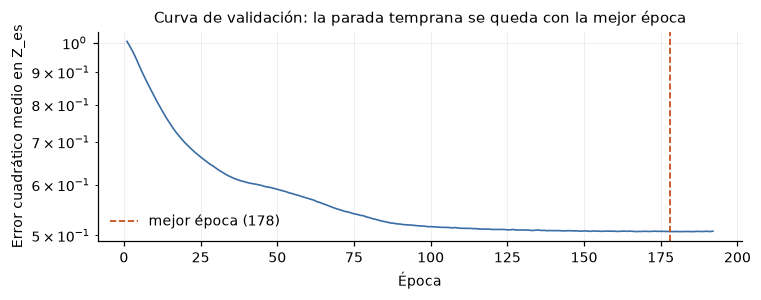

In [7]:
t0 = time.time()
ae, historia = entrenar_autoencoder(Z_tr, Z_es, HP_AE)
mejor_epoca = int(np.argmin(historia)) + 1
print(f"{METODO_AE}: {len(historia)} épocas, mejor en la {mejor_epoca}, {time.time() - t0:.1f} s")

for nombre, Zb in (("entrenamiento Z_tr", Z_tr), ("parada temprana Z_es", Z_es), ("calibración Z_cal", Z_cal)):
    print(f"Error de reconstrucción medio en {nombre:22s}: {error_reconstruccion(ae, Zb).mean():7.2f}")

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.plot(np.arange(1, len(historia) + 1), historia, color=plots.COLORS["normal"])
ax.axvline(mejor_epoca, ls="--", color=plots.COLORS["fault"], label=f"mejor época ({mejor_epoca})")
ax.set_xlabel("Época"); ax.set_ylabel("Error cuadrático medio en Z_es"); ax.set_yscale("log"); ax.legend()
ax.set_title("Curva de validación: la parada temprana se queda con la mejor época")
plt.tight_layout()

### Cómo leerlo

Tres cosas en la salida:
1. **La curva.** El error de validación baja y después se estanca o sube; la línea discontinua marca los pesos con los que se queda la red. Si la mejor época está pegada al final, la paciencia o el máximo de épocas se quedaron cortos.
2. **Los tres errores medios.** `Z_tr` es el único bloque que la red minimizó. Si su error es claramente el menor de los tres, estás viendo el optimismo que obliga a calibrar con reserva: un umbral sacado de `Z_tr` quedaría bajo (sección 5).
3. **`Z_es` frente a `Z_cal`.** Los dos son normales no vistos, pero están en momentos distintos de la misma simulación. Si difieren, parte de la diferencia puede ser deriva del proceso y no sobreajuste; con una sola simulación no se pueden separar.

### Verifícalo tú

Entrena un segundo autoencoder idéntico pero con la parada temprana hecha sobre `Z_cal` en lugar de `Z_es`, y compara el error medio que cada uno tiene en `Z_cal`. ¿Cuál saldría más bajo, y qué le pasaría al umbral calibrado sobre `Z_cal`?

In [8]:
# Verifícalo tú: la parada temprana con el bloque de calibración es una fuga.
# Solución (quita los '# ' de las líneas de abajo y ejecuta):
# ae_fuga, _ = entrenar_autoencoder(Z_tr, Z_cal, HP_AE)        # para mirando Z_cal: MAL
# print("Error medio en Z_cal, parada con Z_es :", round(float(error_reconstruccion(ae, Z_cal).mean()), 2))
# print("Error medio en Z_cal, parada con Z_cal:", round(float(error_reconstruccion(ae_fuga, Z_cal).mean()), 2))
# # Si el segundo es menor, un umbral calibrado sobre Z_cal saldría más bajo de lo que toca:
# # Z_cal dejó de ser virgen porque influyó en una decisión del modelo (cuándo parar).

## 4. Umbral con normales reservados y evaluación de los 21 fallos → `limits.py` y `metrics.py`

El umbral es el percentil `protocolo.alpha` del error de reconstrucción sobre `Z_cal`, con `limits.limit_empirical`: la misma función y el mismo nivel de confianza que se usan para el SPE. Al lado se imprime `limits.limit_kde` (estimación de densidad por núcleos, KDE, *kernel density estimation*), que suaviza la cola cuando hay pocas muestras reservadas. El PCA-SPE se ajusta con los mismos `X_fit` y `X_cal` y con el método de límite del yaml.

Después se evalúan los dos detectores en los 22 ficheros de prueba con `metrics.evaluate_run`, una fila por (método, fallo, simulación), que es el formato común (regla 11). `evaluar_en_clasico` recibe una función que puntúa y un umbral ya calibrado: la vas a reutilizar con tu propio autoencoder en *Te toca*.

In [9]:
e_cal = error_reconstruccion(ae, Z_cal)
umbral_ae = limits.limit_empirical(e_cal, alpha=NIVEL)          # protocolo: normales reservados
umbral_ae_kde = limits.limit_kde(e_cal, alpha=NIVEL)

pca = PCAMonitor(variance=cfg["pca"]["variance"], alpha=NIVEL,
                 spe_method=cfg["pca"]["spe_method"]).fit(X_fit, X_cal=X_cal)

print(f"Umbral del autoencoder, empírico al {NIVEL:.0%} con reserva: {umbral_ae:.2f}")
print(f"Umbral del autoencoder, KDE al {NIVEL:.0%} con reserva     : {umbral_ae_kde:.2f}")
print(f"PCA: {pca.n_components_} componentes; límite del SPE ({cfg['pca']['spe_method']}, con reserva): {pca.spe_limit_:.2f}")

Umbral del autoencoder, empírico al 99% con reserva: 40.21
Umbral del autoencoder, KDE al 99% con reserva     : 41.50
PCA: 27 componentes; límite del SPE (box, con reserva): 23.46


In [10]:
def evaluar_en_clasico(puntuar, umbral, metodo):
    """Una fila por fichero de prueba del clásico con las columnas de evaluate_run (regla 11).

    puntuar(X) devuelve el estadístico por muestra; el umbral ya viene calibrado con reserva.
    d00_te es todo normal: con onset=None solo se calcula la FAR."""
    filas, estad = [], {}
    for fallo, X in PRUEBA_CLASICO.items():
        s = np.asarray(puntuar(X), dtype=float)
        estad[fallo] = s
        onset = None if fallo == 0 else ONSET
        filas.append({"method": metodo, "faultNumber": fallo, "simulationRun": 1,
                      **metrics.evaluate_run(s, umbral, onset, k=K, sample_minutes=MINUTOS)})
    return pd.DataFrame(filas), estad

def retardo_interpretable(res):
    """El retardo solo cuenta donde hay racha confirmada que no es por azar (regla 4)."""
    return res["delay_samples"].where(res["detected"] & ~res["detected_at_chance"])

res_ae, estad_ae = evaluar_en_clasico(lambda X: error_reconstruccion(ae, escalador.transform(X)), umbral_ae, METODO_AE)
res_pca, estad_pca = evaluar_en_clasico(lambda X: pca.score(X)[1], pca.spe_limit_, "PCA-SPE")
res_clasico = pd.concat([res_ae, res_pca], ignore_index=True)
res_clasico["retardo_interpretable"] = retardo_interpretable(res_clasico)

tabla = res_clasico.pivot(index="faultNumber", columns="method",
                          values=["far", "fdr", "retardo_interpretable", "detected_at_chance"])
tabla = tabla.rename(columns={"far": "FAR (sanas)", "fdr": "FDR", "retardo_interpretable": "retardo (muestras)",
                              "detected_at_chance": "¿racha al azar?"})
print("Sin 3, 9 y 15. La fila 0 es d00_te entero (solo FAR). NaN en el retardo = no se interpreta.")
tabla.drop(index=list(DIFICILES)).round(3)

Sin 3, 9 y 15. La fila 0 es d00_te entero (solo FAR). NaN en el retardo = no se interpreta.


FAR (sanas)                    FDR          retardo (muestras)  \
method      AE-MLP-torch   PCA-SPE AE-MLP-torch  PCA-SPE       AE-MLP-torch   
faultNumber                                                                   
0               0.070833  0.028125          NaN      NaN                NaN   
1                0.03125     0.025       0.9975   0.9975                2.0   
2                0.06875      0.05      0.98875  0.98875               10.0   
4                0.03125   0.03125      0.99875  0.98375                2.0   
5                0.03125   0.03125      0.36625  0.29125                0.0   
6                0.00625    0.0125          1.0      1.0                0.0   
7                0.01875    0.0125          1.0      1.0                0.0   
8                  0.025   0.00625      0.98375  0.97375               14.0   
10               0.03125   0.01875      0.66125  0.47125               21.0   
11               0.04375   0.03125      0.75875  0.60875                5.0   
12               0.06875   0.08125      0.99125    0.975                2.0   
13               0.01875    0.0125      0.95375  0.95375               36.0   
14                 0.025   0.03125          1.0  0.99875                0.0   
16               0.21875   0.05625      0.56875  0.40375               20.0   
17               0.01875   0.01875      0.94375    0.945               23.0   
18               0.05625   0.05625         0.91    0.905               80.0   
19                0.0125    0.0125        0.335  0.17875               71.0   
20                 0.025   0.00625        0.635  0.55375               78.0   
21               0.10625   0.05625       0.5725   0.5825              266.0   

                    ¿racha al azar?          
method      PCA-SPE    AE-MLP-torch PCA-SPE  
faultNumber                                  
0               NaN           False   False  
1               2.0           False   False  
2              10.0           False   False  
4               4.0           False   False  
5               2.0           False   False  
6               0.0           False   False  
7               0.0           False   False  
8              21.0           False   False  
10             34.0           False   False  
11              8.0           False   False  
12              2.0           False   False  
13             36.0           False   False  
14              1.0           False   False  
16             35.0           False   False  
17             23.0           False   False  
18             78.0           False   False  
19             80.0           False   False  
20             80.0           False   False  
21            241.0           False   False

In [11]:
print("Fallos difíciles, SIEMPRE aparte (regla 7):")
display(tabla.loc[list(DIFICILES)].round(3))

def resumen_deteccion(res):
    """Resumen hecho a mano: NO usa metrics.summary (defecto I1)."""
    filas = []
    for metodo, g in res.groupby("method"):
        fallos = g[g["faultNumber"] > 0]
        faciles = fallos[~fallos["faultNumber"].isin(DIFICILES)]
        filas.append({
            "method": metodo,
            "FAR d00_te": g.loc[g["faultNumber"] == 0, "far"].mean(),
            "FAR media prefallo (21 ficheros)": fallos["far"].mean(),
            "FDR media sin 3/9/15": faciles["fdr"].mean(),
            "FDR media 3/9/15": fallos.loc[fallos["faultNumber"].isin(DIFICILES), "fdr"].mean(),
            "retardo medio interpretable sin 3/9/15": faciles["retardo_interpretable"].mean(),
            "fallos con retardo no interpretable": sorted(
                fallos.loc[fallos["retardo_interpretable"].isna(), "faultNumber"].tolist()),
        })
    return pd.DataFrame(filas).set_index("method")

print("Resumen (una simulación por fallo: orientativo, sin contraste posible):")
resumen_deteccion(res_clasico).round(3)

Fallos difíciles, SIEMPRE aparte (regla 7):


FAR (sanas)                   FDR          retardo (muestras)  \
method      AE-MLP-torch  PCA-SPE AE-MLP-torch  PCA-SPE       AE-MLP-torch   
faultNumber                                                                  
3                 0.1125    0.125      0.09375   0.0375                NaN   
9                 0.1125  0.04375      0.10375   0.0575                2.0   
15                  0.05  0.03125       0.1625  0.08375               90.0   

                    ¿racha al azar?          
method      PCA-SPE    AE-MLP-torch PCA-SPE  
faultNumber                                  
3               NaN            True    True  
9               NaN           False    True  
15              NaN           False    True

Resumen (una simulación por fallo: orientativo, sin contraste posible):


,FAR d00_te,FAR media prefallo (21 ficheros),FDR media sin 3/9/15,FDR media 3/9/15,retardo medio interpretable sin 3/9/15,fallos con retardo no interpretable
method,,,,,,
AE-MLP-torch,0.071,0.053,0.815,0.12,35.0,[3]
PCA-SPE,0.028,0.036,0.767,0.06,36.5,"[3, 9, 15]"


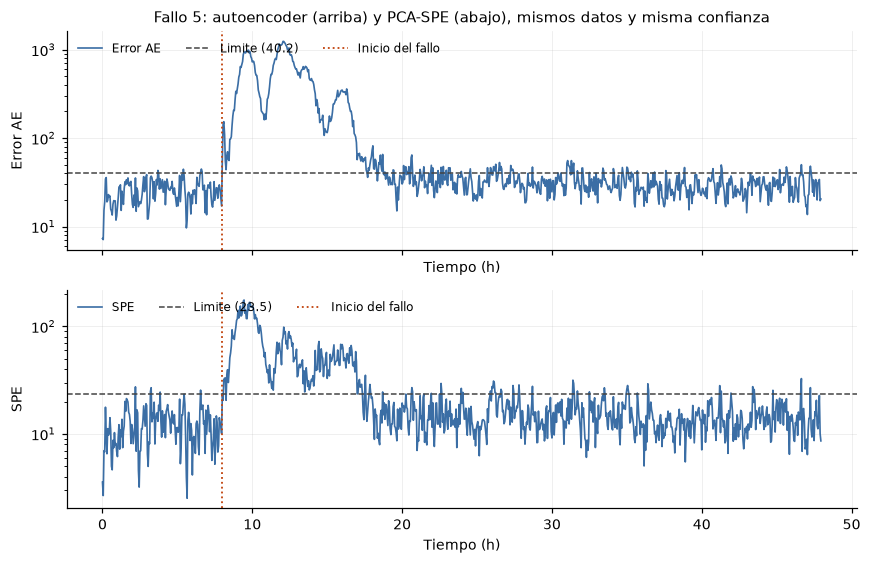

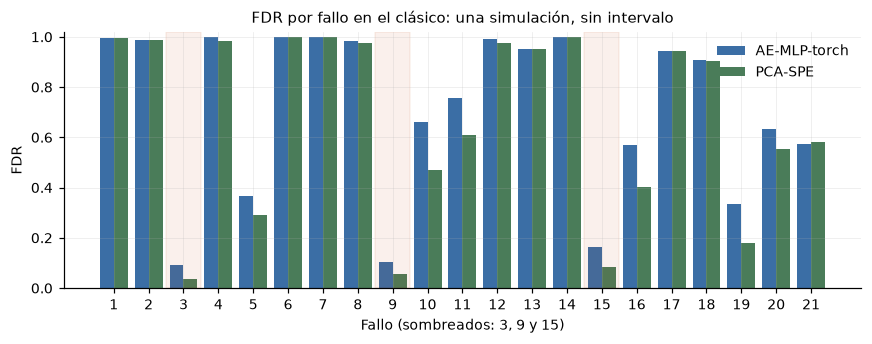

In [12]:
FALLO_CARTA = 5          # cámbialo para ver otro fallo con los dos detectores
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5.2), sharex=True)
plots.control_chart(estad_ae[FALLO_CARTA], umbral_ae, onset=ONSET, ylabel="Error AE", ax=ax1, sample_minutes=MINUTOS)
plots.control_chart(estad_pca[FALLO_CARTA], pca.spe_limit_, onset=ONSET, ylabel="SPE", ax=ax2, sample_minutes=MINUTOS)
ax1.set_title(f"Fallo {FALLO_CARTA}: autoencoder (arriba) y PCA-SPE (abajo), mismos datos y misma confianza")
plt.tight_layout()

fig, ax = plt.subplots(figsize=(8, 3.2))
for i, (metodo, g) in enumerate(res_clasico[res_clasico["faultNumber"] > 0].groupby("method")):
    ax.bar(g["faultNumber"] + (i - 0.5) * 0.4, g["fdr"], width=0.4, label=metodo,
           color=[plots.COLORS["normal"], plots.COLORS["alt1"]][i])
for f in DIFICILES:
    ax.axvspan(f - 0.5, f + 0.5, color=plots.COLORS["fault"], alpha=0.08)
ax.set_xticks(range(1, 22)); ax.set_xlabel("Fallo (sombreados: 3, 9 y 15)"); ax.set_ylabel("FDR")
ax.set_ylim(0, 1.02); ax.legend(); ax.set_title("FDR por fallo en el clásico: una simulación, sin intervalo")
plt.tight_layout()

### Cómo leerlo

Lee las tablas en este orden:
1. **La FAR, primero.** La fila 0 es `d00_te` entero; en las demás, la FAR sale de las 160 muestras previas de cada fichero. Con un límite al nivel `protocolo.alpha` esperarías algo del orden de 1 − alpha (con el percentil empírico y pocas muestras reservadas, algo más: el percentil de una muestra pequeña tiende a quedarse corto). Si un detector se aleja mucho de eso aun calibrado con reserva, no compares todavía su FDR con la del otro: un detector que alarma más, detecta más.
2. **FDR y retardo, juntos.** El retardo solo aparece donde hay racha de k alarmas y la FDR no baja de 0,10; donde ves `NaN`, o no hubo racha o fue por azar (columna `¿racha al azar?`), y no se interpreta.
3. **3, 9 y 15, aparte.** Si alguno de los dos los «detecta» con una FDR del orden de su FAR, no es detección: es la tasa de falsas alarmas vista dentro del tramo con fallo.
4. **El resumen** está hecho a mano por el defecto I1, y su última columna dice en qué fallos el retardo no cuenta.
5. **Las figuras**: en la carta, mira si el estadístico supera el umbral ya antes de la línea del fallo (falsas alarmas) y si se queda arriba o vuelve a bajar después (compáralo con el caso del fallo 5 en el 01). En las barras, cada par es el mismo fichero puntuado por los dos detectores.

Y lo más importante: **es una sola simulación por fallo**. Ninguna diferencia entre el autoencoder y el PCA en estas tablas es un resultado, porque no hay contraste posible (regla 8). Para eso está la sección 6.

### Verifícalo tú

Cambia el umbral empírico por el de KDE (`umbral_ae_kde`) y mira qué le pasa a la FAR sobre `d00_te`. ¿Cuál de los dos esperarías que se comporte mejor con muy pocas muestras reservadas, y por qué?

In [13]:
# Verifícalo tú: umbral empírico frente a KDE, mismo modelo y mismos datos reservados.
# Solución (quita los '# ' de las líneas de abajo y ejecuta):
# for nombre, u in (("empírico", umbral_ae), ("KDE", umbral_ae_kde)):
#     r = metrics.evaluate_run(estad_ae[0], u, None)
#     print(f"Umbral {nombre:8s}: {u:6.2f} -> FAR en d00_te = {r['far']:.3f}")
# # Con pocas muestras, el percentil empírico al 99 % se apoya en uno o dos valores extremos;
# # la KDE interpola la cola y suele ser más estable, aunque depende del ancho de banda.

## 5. Las dos trampas del protocolo, medidas → `limits.py` y `metrics.py`

Esta es la sección que conecta el cuaderno con tu OE3: **atribuir las diferencias a los componentes del protocolo**. La receta es la de todo el TFM: mismo modelo, mismos datos, y se cambia **un solo** componente.

- **Trampa (a): umbral calibrado con los datos del entrenamiento.** Para el autoencoder, el percentil del error sobre `Z_tr`, que es lo que la red minimizó; para el PCA, `PCAMonitor` sin `X_cal` y con las mismas cargas. Es lo que hace buena parte de la literatura: Lyu et al. (2026) fijan el umbral de sus autoencoders sobre la distribución de entrenamiento (sección 9).
- **Trampa (b): umbral elegido maximizando el F1 sobre la PRUEBA.** Se juntan todas las muestras de prueba con su etiqueta (sana o con fallo), se barren todos los umbrales posibles y se queda el de mayor puntuación F1 (*F1 score*). Es fuga de datos en estado puro: el umbral es un parámetro del detector y se ajusta con las etiquetas de la prueba. En planta no hay etiquetas, así que ese umbral no se puede reproducir; y si cada método recibe su umbral oráculo, la comparación entre métodos deja de medir los métodos.
- **Control: el detector trivial**, que lo marca todo como fallo (FAR = FDR = 1). Sirve para comprobar si la métrica discrimina: si el F1 de un método se parece al del trivial, ese F1 no está diciendo nada. Es la idea de Kim et al. (2022) que el traspaso propone como control.

La piscina de la trampa (b) son las 22 simulaciones de prueba: `d00_te` entero como sano, las 160 primeras muestras de cada fichero de fallo como sanas y las 800 restantes como fallo. La celda imprime la prevalencia (*prevalence*, la fracción de muestras con fallo): tenla presente al leer el F1.

In [14]:
def umbral_que_maximiza_f1(s, y):
    """Barre todos los umbrales posibles (alarma si s > u) y devuelve el de mayor F1.
    ESTO ES LA TRAMPA (b): solo se puede calcular con las etiquetas de la prueba."""
    s, y = np.asarray(s, float), np.asarray(y, int)
    candidatos = np.r_[-np.inf, np.unique(s)]                          # -inf = detector trivial
    pos, neg = np.sort(s[y == 1]), np.sort(s[y == 0])
    vp = len(pos) - np.searchsorted(pos, candidatos, side="right")    # verdaderos positivos
    fp = len(neg) - np.searchsorted(neg, candidatos, side="right")    # falsos positivos
    fn = len(pos) - vp
    f1 = 2 * vp / np.maximum(2 * vp + fp + fn, 1)
    return float(candidatos[np.argmax(f1)])

def piscina_clasico(estad):
    """Todas las muestras de prueba del clásico con etiqueta 0 (sana) o 1 (fallo activo)."""
    s = np.concatenate([estad[f] for f in range(22)])
    y = np.concatenate([np.zeros(len(estad[0]), int)] +
                       [(np.arange(len(estad[f])) >= ONSET).astype(int) for f in range(1, 22)])
    return s, y

def medir_umbral(estad, umbral):
    """FAR, FDR y F1 de un umbral sobre la prueba del clásico."""
    s, y = piscina_clasico(estad)
    faciles = [f for f in range(1, 22) if f not in DIFICILES]
    return {
        "umbral": umbral,
        "FAR d00_te": metrics.far(estad[0], umbral),
        "FAR media prefallo": np.mean([metrics.far(estad[f][:ONSET], umbral) for f in range(1, 22)]),
        "FDR media sin 3/9/15": np.mean([metrics.fdr(estad[f][ONSET:], umbral) for f in faciles]),
        "FDR media 3/9/15": np.mean([metrics.fdr(estad[f][ONSET:], umbral) for f in DIFICILES]),
        "F1 en la prueba": f1_score(y, s > umbral, zero_division=0),
    }

In [15]:
# (a) Mismo modelo; umbral calibrado con los datos del entrenamiento
umbral_ae_en_muestra = limits.limit_empirical(error_reconstruccion(ae, Z_tr), alpha=NIVEL)
pca_en_muestra = PCAMonitor(n_components=pca.n_components_, alpha=NIVEL,
                            spe_method=cfg["pca"]["spe_method"]).fit(X_fit)          # sin X_cal
assert np.allclose(pca_en_muestra.loadings_, pca.loadings_)   # mismo modelo: solo cambia el límite

# (b) Umbral que maximiza el F1 sobre la PRUEBA (fuga)
umbral_ae_f1 = umbral_que_maximiza_f1(*piscina_clasico(estad_ae))
umbral_pca_f1 = umbral_que_maximiza_f1(*piscina_clasico(estad_pca))

variantes = {
    METODO_AE: (estad_ae, {"protocolo (reservado)": umbral_ae, "(a) en muestra": umbral_ae_en_muestra,
                           "(b) F1 máximo en la prueba": umbral_ae_f1, "control: detector trivial": -np.inf}),
    "PCA-SPE": (estad_pca, {"protocolo (reservado)": pca.spe_limit_, "(a) en muestra": pca_en_muestra.spe_limit_,
                            "(b) F1 máximo en la prueba": umbral_pca_f1, "control: detector trivial": -np.inf}),
}
trampas = pd.DataFrame([{"method": familia, "variante": nombre, **medir_umbral(estad, u)}
                        for familia, (estad, umbrales) in variantes.items()
                        for nombre, u in umbrales.items()]).set_index(["method", "variante"])

_, y_piscina = piscina_clasico(estad_ae)
print(f"Prevalencia de la piscina de prueba: {y_piscina.mean():.3f} (fracción de muestras con fallo)")
trampas.round(3)

Prevalencia de la piscina de prueba: 0.795 (fracción de muestras con fallo)


umbral  FAR d00_te  \
method       variante                                         
AE-MLP-torch protocolo (reservado)       40.211       0.071   
             (a) en muestra              26.220       0.508   
             (b) F1 máximo en la prueba  21.205       0.775   
             control: detector trivial     -inf       1.000   
PCA-SPE      protocolo (reservado)       23.456       0.028   
             (a) en muestra              14.820       0.319   
             (b) F1 máximo en la prueba   8.225       0.842   
             control: detector trivial     -inf       1.000   

                                         FAR media prefallo  \
method       variante                                         
AE-MLP-torch protocolo (reservado)                    0.053   
             (a) en muestra                           0.438   
             (b) F1 máximo en la prueba               0.686   
             control: detector trivial                1.000   
PCA-SPE      protocolo (reservado)                    0.036   
             (a) en muestra                           0.274   
             (b) F1 máximo en la prueba               0.800   
             control: detector trivial                1.000   

                                         FDR media sin 3/9/15  \
method       variante                                           
AE-MLP-torch protocolo (reservado)                      0.815   
             (a) en muestra                             0.944   
             (b) F1 máximo en la prueba                 0.979   
             control: detector trivial                  1.000   
PCA-SPE      protocolo (reservado)                      0.767   
             (a) en muestra                             0.891   
             (b) F1 máximo en la prueba                 0.986   
             control: detector trivial                  1.000   

                                         FDR media 3/9/15  F1 en la prueba  
method       variante                                                       
AE-MLP-torch protocolo (reservado)                  0.120            0.827  
             (a) en muestra                         0.590            0.889  
             (b) F1 máximo en la prueba             0.819            0.894  
             control: detector trivial              1.000            0.886  
PCA-SPE      protocolo (reservado)                  0.060            0.795  
             (a) en muestra                         0.366            0.864  
             (b) F1 máximo en la prueba             0.871            0.891  
             control: detector trivial              1.000            0.886

In [16]:
# Atribución: cuánto mueve cada componente las métricas respecto al protocolo, dentro de cada familia.
metricas_trampa = trampas.drop(columns="umbral")
efectos = metricas_trampa.sub(metricas_trampa.xs("protocolo (reservado)", level="variante"), level="method")
display(efectos.drop(index="protocolo (reservado)", level="variante").round(3))

for familia in variantes:
    t = trampas.loc[familia]
    print(f"{familia}: ¿(a) da más FAR prefallo que el protocolo? "
          f"{'sí' if t.loc['(a) en muestra', 'FAR media prefallo'] > t.loc['protocolo (reservado)', 'FAR media prefallo'] else 'no'}"
          f" | F1 de (b) menos F1 del detector trivial: "
          f"{t.loc['(b) F1 máximo en la prueba', 'F1 en la prueba'] - t.loc['control: detector trivial', 'F1 en la prueba']:+.3f}")

FAR d00_te  FAR media prefallo  \
method       variante                                                     
AE-MLP-torch (a) en muestra                   0.438               0.385   
             (b) F1 máximo en la prueba       0.704               0.633   
             control: detector trivial        0.929               0.947   
PCA-SPE      (a) en muestra                   0.291               0.238   
             (b) F1 máximo en la prueba       0.814               0.765   
             control: detector trivial        0.972               0.964   

                                         FDR media sin 3/9/15  \
method       variante                                           
AE-MLP-torch (a) en muestra                             0.129   
             (b) F1 máximo en la prueba                 0.164   
             control: detector trivial                  0.185   
PCA-SPE      (a) en muestra                             0.124   
             (b) F1 máximo en la prueba                 0.219   
             control: detector trivial                  0.233   

                                         FDR media 3/9/15  F1 en la prueba  
method       variante                                                       
AE-MLP-torch (a) en muestra                         0.470            0.062  
             (b) F1 máximo en la prueba             0.699            0.067  
             control: detector trivial              0.880            0.059  
PCA-SPE      (a) en muestra                         0.307            0.069  
             (b) F1 máximo en la prueba             0.811            0.095  
             control: detector trivial              0.940            0.091

AE-MLP-torch: ¿(a) da más FAR prefallo que el protocolo? sí | F1 de (b) menos F1 del detector trivial: +0.008
PCA-SPE: ¿(a) da más FAR prefallo que el protocolo? sí | F1 de (b) menos F1 del detector trivial: +0.005


### Cómo leerlo

Recorre la tabla de efectos fila a fila: cada fila cambia un solo componente respecto al protocolo, y la celda de abajo lo resume en dos preguntas.
- **(a) en muestra.** Mira el signo de la diferencia en FAR, familia por familia. En el PCA es el mismo efecto que A0 mide con su configuración completa; aquí lo ves también en el autoencoder con el mismo diseño. No des el signo por supuesto: Vanhatalo y Kulahci (2016) muestran que la autocorrelación puede bajar la FAR, así que se reporta lo que sale, con su configuración. Fíjate también en la FDR: un umbral más bajo detecta más, y esa «mejora» es la que se publica cuando nadie mira la FAR.
- **(b) F1 máximo en la prueba.** El F1 de (b) no puede ser menor que el del protocolo, porque es el máximo sobre todos los umbrales, calculado con las mismas etiquetas con las que se evalúa. Esa diferencia es inflado puro, no mérito del modelo. Mira qué le cuesta en FAR y compara su F1 con el del detector trivial: con la prevalencia que imprime la celda, el F1 premia alarmar, y el umbral «óptimo» se acerca a marcarlo todo.
- **La lección para tu comparación con Lyu:** una exactitud o un F1 sin decir de dónde sale el umbral no se puede comparar con nada. En tu tabla de atribución, cada fila tiene que decir qué componente cambió.

Con una simulación por fallo esto es orientativo: la sección 6 repite la trampa (a) con varias simulaciones y con intervalo.

### Verifícalo tú

El detector trivial tiene recall 1 y precisión igual a la prevalencia p, así que su F1 es 2p/(1+p). Calcúlalo a mano con `y_piscina` y compáralo con la fila «control: detector trivial» de la tabla.

In [17]:
# Verifícalo tú: el F1 del detector trivial depende solo de la prevalencia.
# Solución (quita los '# ' de las líneas de abajo y ejecuta):
# p = y_piscina.mean()                                     # prevalencia de muestras con fallo
# print("F1 del detector trivial a mano :", round(2 * p / (1 + p), 4))
# print("F1 del detector trivial medido :", round(f1_score(y_piscina, np.ones_like(y_piscina)), 4))

## 6. Rieth con varias simulaciones → `data.load_rieth`, `metrics.aggregate` y `stats.compare_methods`

Con una sola simulación por fallo no hay intervalo ni contraste. Rieth trae 500 simulaciones por condición; aquí se usa un subconjunto de desarrollo, `datos.runs_desarrollo` del yaml, para que corra en pocos minutos. Los resultados de la memoria se harán con `datos.runs_finales`.

Cómo se reparten las simulaciones, **una sola vez** y con los mismos ids para todas las clases (regla 1):
- `data.split_runs(500, fracciones del yaml, semilla)` da tres listas de ids: ajuste, validación y prueba.
- **Detección** (solo normales, `train_fault00`): la red entrena con ids de ajuste, para con ids de validación y el umbral se calibra con **otros** ids de validación. El reparto entre los tres papeles sigue las fracciones del yaml (`calibracion_limites` para calibrar).
- **Prueba**: ids de prueba en los ficheros `test_faultNN`, que no comparten semillas con los de entrenamiento.
- Todas las llamadas a `data.load_rieth` llevan `root=RIETH_DIR`, reciben listas de `int` de Python y se comprueba `nunique()`, porque los ids que no existen se ignoran sin aviso (DAT-6 del informe de datos de Rieth del 27/09, que te puede pasar Pablo). Los ids se convierten a `int64` al cargar: vienen en `int16` y la aritmética con ellos se desborda (DAT-5).

Dos cuidados que vienen de los datos (DAT-1 del mismo informe):
- La simulación normal r y la de fallo r de un mismo fichero comparten semilla: son la misma trayectoria hasta que entra el fallo. Por eso **la FAR se mide en `test_fault00`, por simulación**, y no en las 160 muestras previas de cada fichero de fallo, que son copias de esas mismas simulaciones normales (la columna `far` de los fallos repite la misma medida).
- El inicio nominal no siempre es el efectivo: en algunos fallos la trayectoria sigue idéntica a su gemela normal varias muestras después del inicio. La celda «El inicio efectivo del fallo», al final de esta sección, lo mide con las simulaciones de prueba ya cargadas. Donde ese retraso no es cero, parte del retardo es física del proceso y no defecto del detector.

**Todo esto es desarrollo.** Los ids que carga esta sección (los guarda `C00_configuracion.json`) quedan mirados y no sirven para el resultado confirmatorio del OE3: esos ids se declaran aparte, antes de ejecutar (`docs/reglas_de_medida.md`, regla 3).

In [18]:
ID = ["faultNumber", "simulationRun", "sample"]
if not HAY_RIETH:
    print(MENSAJE_SIN_RIETH)
else:
    tr_ids, va_ids, te_ids = data.split_runs(500, fractions=FRACCIONES, seed=SEMILLA)   # UNA vez

    n_cal_R = int(round(N_DESARROLLO * F_CAL))
    n_es_R = int(round(N_DESARROLLO * FRACCIONES[1]))
    n_fit_R = N_DESARROLLO - n_cal_R - n_es_R
    ids_fit = [int(i) for i in tr_ids[:n_fit_R]]                   # entrenar la red
    ids_es = [int(i) for i in va_ids[:n_es_R]]                     # parada temprana
    ids_cal = [int(i) for i in va_ids[n_es_R:n_es_R + n_cal_R]]    # calibrar el umbral
    ids_prueba = [int(i) for i in te_ids[:N_DESARROLLO]]           # prueba (ficheros test_faultNN)
    assert not (set(ids_fit) & set(ids_es)) and not (set(ids_es) & set(ids_cal))

    normales = data.load_rieth(0, "train", runs=ids_fit + ids_es + ids_cal, root=RIETH_DIR)
    normales[ID] = normales[ID].astype("int64")                    # int16 -> int64 (DAT-5)
    assert normales["simulationRun"].nunique() == N_DESARROLLO     # DAT-6

    def bloque(ids):
        return data.values(normales[normales["simulationRun"].isin(ids)])

    XR_fit, XR_cal = bloque(ids_fit + ids_es), bloque(ids_cal)
    escalador_R = Scaler().fit(XR_fit)                             # regla 2
    ZR_tr, ZR_es, ZR_cal = (escalador_R.transform(bloque(i)) for i in (ids_fit, ids_es, ids_cal))
    print(f"Simulaciones normales: {n_fit_R} para entrenar, {n_es_R} para parar y {n_cal_R} para calibrar "
          f"({len(ZR_tr)}, {len(ZR_es)} y {len(ZR_cal)} muestras)")
    print(f"Prueba: {len(ids_prueba)} simulaciones por clase | inicio del fallo en Rieth: entrenamiento "
          f"{data.fault_onset('train', 'rieth')}, prueba {data.fault_onset('test', 'rieth')}")

Simulaciones normales: 10 para entrenar, 4 para parar y 6 para calibrar (5000, 2000 y 3000 muestras)
Prueba: 20 simulaciones por clase | inicio del fallo en Rieth: entrenamiento 20, prueba 160


In [19]:
if HAY_RIETH:
    HP_AE_R = {**HP_AE, "lote": 64, "epocas_max": 200, "paciencia": 15}   # más datos: lotes mayores
    t0 = time.time()
    ae_R, historia_R = entrenar_autoencoder(ZR_tr, ZR_es, HP_AE_R)
    print(f"{METODO_AE} en Rieth: {len(historia_R)} épocas (mejor, la {int(np.argmin(historia_R)) + 1}), "
          f"{time.time() - t0:.1f} s")

    umbral_R = limits.limit_empirical(error_reconstruccion(ae_R, ZR_cal), alpha=NIVEL)            # protocolo
    umbral_R_en_muestra = limits.limit_empirical(error_reconstruccion(ae_R, ZR_tr), alpha=NIVEL)  # trampa (a)
    pca_R = PCAMonitor(variance=cfg["pca"]["variance"], alpha=NIVEL,
                       spe_method=cfg["pca"]["spe_method"]).fit(XR_fit, X_cal=XR_cal)
    pca_R_en_muestra = PCAMonitor(n_components=pca_R.n_components_, alpha=NIVEL,
                                  spe_method=cfg["pca"]["spe_method"]).fit(XR_fit)
    assert np.allclose(pca_R_en_muestra.loadings_, pca_R.loadings_)
    print(f"Umbral del AE: {umbral_R:.2f} con reserva | {umbral_R_en_muestra:.2f} en muestra")
    print(f"PCA: {pca_R.n_components_} componentes; límite del SPE {pca_R.spe_limit_:.2f} con reserva | "
          f"{pca_R_en_muestra.spe_limit_:.2f} en muestra")

AE-MLP-torch en Rieth: 65 épocas (mejor, la 58), 25.0 s
Umbral del AE: 33.80 con reserva | 31.44 en muestra
PCA: 27 componentes; límite del SPE 16.54 con reserva | 16.15 en muestra


In [20]:
if HAY_RIETH:
    t0 = time.time()
    ONSET_R = data.fault_onset("test", "rieth")
    prueba_R, estad_R, filas = {}, {}, []
    for fallo in range(21):                                   # Rieth: 0..20, no tiene fallo 21
        d = data.load_rieth(fallo, "test", runs=ids_prueba, root=RIETH_DIR)
        d[ID] = d[ID].astype("int64")
        assert d["simulationRun"].nunique() == len(ids_prueba)
        prueba_R[fallo] = d                                   # se reutiliza en la sección 7
        onset = None if fallo == 0 else ONSET_R               # test_fault00: solo FAR, por simulación
        for sim, g in d.groupby("simulationRun"):
            X = data.values(g.sort_values("sample"))
            e = error_reconstruccion(ae_R, escalador_R.transform(X))
            spe = pca_R.score(X)[1]                           # el PCA en muestra tiene el mismo SPE
            estad_R[(fallo, sim)] = (e, spe)
            for metodo, s, u in ((METODO_AE, e, umbral_R),
                                 (f"{METODO_AE}|umbral-en-muestra", e, umbral_R_en_muestra),
                                 ("PCA-SPE", spe, pca_R.spe_limit_),
                                 ("PCA-SPE|umbral-en-muestra", spe, pca_R_en_muestra.spe_limit_)):
                filas.append({"method": metodo, "faultNumber": fallo, "simulationRun": sim,
                              **metrics.evaluate_run(s, u, onset, k=K, sample_minutes=MINUTOS)})
    res_R = pd.DataFrame(filas)
    res_R["retardo_interpretable"] = retardo_interpretable(res_R)
    print(f"{len(res_R)} filas (método, fallo, simulación) en {time.time() - t0:.1f} s")

1680 filas (método, fallo, simulación) en 10.1 s


FDR media e IC al 95 % sobre 20 simulaciones por fallo (sin 3, 9 y 15):


fdr_mean           fdr_ci_low          fdr_ci_high          \
method      AE-MLP-torch PCA-SPE AE-MLP-torch PCA-SPE AE-MLP-torch PCA-SPE   
faultNumber                                                                  
1                  0.996   0.997        0.996   0.997        0.997   0.997   
2                  0.987   0.985        0.986   0.984        0.988   0.986   
4                  0.992   0.999        0.991   0.999        0.994   1.000   
5                  0.245   0.131        0.232   0.121        0.259   0.141   
6                  1.000   1.000        1.000   1.000        1.000   1.000   
7                  1.000   1.000        1.000   1.000        1.000   1.000   
8                  0.964   0.925        0.953   0.902        0.976   0.948   
10                 0.142   0.219        0.115   0.194        0.170   0.243   
11                 0.683   0.703        0.668   0.687        0.699   0.720   
12                 0.981   0.953        0.977   0.942        0.986   0.963   
13                 0.950   0.948        0.940   0.936        0.960   0.959   
14                 1.000   0.999        0.999   0.999        1.000   1.000   
16                 0.086   0.167        0.075   0.154        0.098   0.181   
17                 0.886   0.912        0.874   0.900        0.899   0.925   
18                 0.926   0.929        0.911   0.914        0.941   0.944   
19                 0.068   0.064        0.060   0.058        0.077   0.070   
20                 0.427   0.500        0.420   0.493        0.433   0.506   

            at_chance_ratio         retardo_interp_medio          \
method         AE-MLP-torch PCA-SPE         AE-MLP-torch PCA-SPE   
faultNumber                                                        
1                      0.00    0.00                2.900   2.400   
2                      0.00    0.00               11.400  12.500   
4                      0.00    0.00                0.500   0.500   
5                      0.00    0.10                1.000   1.167   
6                      0.00    0.00                0.000   0.000   
7                      0.00    0.00                0.000   0.000   
8                      0.00    0.00               21.750  24.950   
10                     0.25    0.00              166.333  99.450   
11                     0.00    0.00                7.550   6.900   
12                     0.00    0.00               10.500  10.700   
13                     0.00    0.00               40.250  38.800   
14                     0.00    0.00                0.300   0.500   
16                     0.80    0.00               59.750  75.000   
17                     0.00    0.00               32.750  31.750   
18                     0.00    0.00               60.250  58.200   
19                     0.60    0.65              117.000     NaN   
20                     0.00    0.00               52.550  49.850   

            n_retardo_interp          
method          AE-MLP-torch PCA-SPE  
faultNumber                           
1                       20.0    20.0  
2                       20.0    20.0  
4                       20.0    20.0  
5                       20.0    18.0  
6                       20.0    20.0  
7                       20.0    20.0  
8                       20.0    20.0  
10                      15.0    20.0  
11                      20.0    20.0  
12                      20.0    20.0  
13                      20.0    20.0  
14                      20.0    20.0  
16                       4.0    20.0  
17                      20.0    20.0  
18                      20.0    20.0  
19                       1.0     0.0  
20                      20.0    20.0

Fallos difíciles, aparte:


fdr_mean           fdr_ci_low          fdr_ci_high          \
method      AE-MLP-torch PCA-SPE AE-MLP-torch PCA-SPE AE-MLP-torch PCA-SPE   
faultNumber                                                                  
3                  0.009   0.012        0.006   0.010        0.011   0.014   
9                  0.009   0.012        0.007   0.010        0.011   0.014   
15                 0.009   0.013        0.007   0.011        0.012   0.015   

            at_chance_ratio         retardo_interp_medio          \
method         AE-MLP-torch PCA-SPE         AE-MLP-torch PCA-SPE   
faultNumber                                                        
3                      0.15     0.0                  NaN     NaN   
9                      0.05     0.0                  NaN     NaN   
15                     0.10     0.0                  NaN     NaN   

            n_retardo_interp          
method          AE-MLP-torch PCA-SPE  
faultNumber                           
3                        0.0     0.0  
9                        0.0     0.0  
15                       0.0     0.0

FAR por simulación en test_fault00 (media e IC al 95 %):


,n_runs,far_mean,far_ci_low,far_ci_high
method,,,,
AE-MLP-torch,20,0.008,0.0056,0.0104
PCA-SPE,20,0.011,0.0090,0.0130


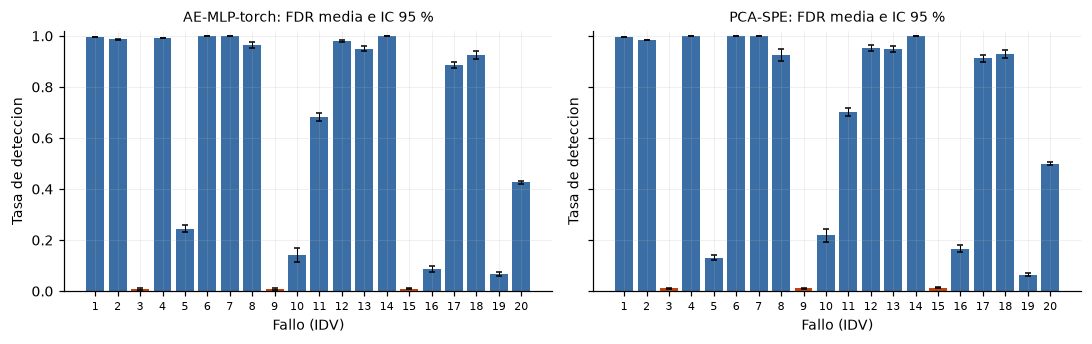

In [21]:
if HAY_RIETH:
    principales = [METODO_AE, "PCA-SPE"]
    sub = res_R[res_R["method"].isin(principales)]
    agg_R = metrics.aggregate(sub, by=["method", "faultNumber"])
    ret = (sub.groupby(["method", "faultNumber"])["retardo_interpretable"].agg(["mean", "count"])
           .rename(columns={"mean": "retardo_interp_medio", "count": "n_retardo_interp"}).reset_index())
    agg_R = agg_R.merge(ret, on=["method", "faultNumber"])
    cols = ["fdr_mean", "fdr_ci_low", "fdr_ci_high", "at_chance_ratio", "retardo_interp_medio", "n_retardo_interp"]
    tabla_R = agg_R[agg_R["faultNumber"] > 0].pivot(index="faultNumber", columns="method", values=cols)

    print(f"FDR media e IC al 95 % sobre {len(ids_prueba)} simulaciones por fallo (sin 3, 9 y 15):")
    display(tabla_R.drop(index=list(DIFICILES)).round(3))
    print("Fallos difíciles, aparte:")
    display(tabla_R.loc[list(DIFICILES)].round(3))
    print("FAR por simulación en test_fault00 (media e IC al 95 %):")
    display(agg_R[agg_R["faultNumber"] == 0].set_index("method")[["n_runs", "far_mean", "far_ci_low", "far_ci_high"]].round(4))

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
    for ax, metodo in zip(axes, principales):
        plots.fdr_by_fault(agg_R[agg_R["method"] == metodo], ax=ax)
        ax.set_title(f"{metodo}: FDR media e IC 95 %", fontsize=9)
    plt.tight_layout()

In [22]:
if HAY_RIETH:
    # Contraste pareado por simulación con Holm por fallo (regla 8). Con dos métodos hay un solo par por fallo.
    contraste = stats.compare_methods(sub[sub["faultNumber"] > 0], metric="fdr")
    contraste = contraste[["faultNumber", "method_a", "method_b", "n", "median_difference", "p_value", "significant"]]
    print(f"median_difference = FDR de {contraste['method_a'].iat[0]} menos FDR de {contraste['method_b'].iat[0]}, "
          f"mediana de las diferencias por simulación; alfa de contraste {ALPHA_CONTRASTES}")
    display(contraste.round(4))

median_difference = FDR de AE-MLP-torch menos FDR de PCA-SPE, mediana de las diferencias por simulación; alfa de contraste 0.05


,faultNumber,method_a,method_b,n,median_difference,p_value,significant
0,1,AE-MLP-torch,PCA-SPE,20,-0.0006,0.0032,True
1,2,AE-MLP-torch,PCA-SPE,20,0.0019,0.0005,True
2,3,AE-MLP-torch,PCA-SPE,20,-0.0031,0.0227,True
3,4,AE-MLP-torch,PCA-SPE,20,-0.0075,0.0001,True
4,5,AE-MLP-torch,PCA-SPE,20,0.1231,0.0001,True
5,6,AE-MLP-torch,PCA-SPE,20,0.0000,1.0000,False
6,7,AE-MLP-torch,PCA-SPE,20,0.0000,1.0000,False
7,8,AE-MLP-torch,PCA-SPE,20,0.0256,0.0001,True
8,9,AE-MLP-torch,PCA-SPE,20,-0.0038,0.0075,True
9,10,AE-MLP-torch,PCA-SPE,20,-0.0738,0.0001,True


In [23]:
if HAY_RIETH:
    # Trampa (a) con varias simulaciones: FAR por simulación normal de prueba, umbral reservado o en muestra.
    normales_R = res_R[res_R["faultNumber"] == 0]
    far_a = metrics.aggregate(normales_R, by="method").set_index("method")
    display(far_a[["n_runs", "far_mean", "far_ci_low", "far_ci_high"]].round(4))
    faciles_R = res_R[(res_R["faultNumber"] > 0) & ~res_R["faultNumber"].isin(DIFICILES)]
    for familia in principales:
        a = normales_R[normales_R["method"] == f"{familia}|umbral-en-muestra"].set_index("simulationRun")["far"]
        b = normales_R[normales_R["method"] == familia].set_index("simulationRun")["far"].loc[a.index]
        r = stats.paired_test(a.to_numpy(), b.to_numpy())
        dfdr = (faciles_R.loc[faciles_R["method"] == f"{familia}|umbral-en-muestra", "fdr"].mean()
                - faciles_R.loc[faciles_R["method"] == familia, "fdr"].mean())
        print(f"{familia}: FAR en muestra menos reservada, mediana de la diferencia pareada "
              f"{r['median_difference']:+.4f} (Wilcoxon p = {r['p_value']:.3g}, n = {r['n']}); "
              f"FDR media sin 3/9/15, en muestra menos reservada: {dfdr:+.4f}")

,n_runs,far_mean,far_ci_low,far_ci_high
method,,,,
AE-MLP-torch,20,0.0080,0.0056,0.0104
AE-MLP-torch|umbral-en-muestra,20,0.0179,0.0143,0.0215
PCA-SPE,20,0.0110,0.0090,0.0130
PCA-SPE|umbral-en-muestra,20,0.0136,0.0116,0.0156


AE-MLP-torch: FAR en muestra menos reservada, mediana de la diferencia pareada +0.0089 (Wilcoxon p = 8.72e-05, n = 20); FDR media sin 3/9/15, en muestra menos reservada: +0.0177
PCA-SPE: FAR en muestra menos reservada, mediana de la diferencia pareada +0.0026 (Wilcoxon p = 0.000106, n = 20); FDR media sin 3/9/15, en muestra menos reservada: +0.0050


### Cómo leerlo

- **La anchura de los intervalos.** Con varias simulaciones cada FDR lleva su intervalo de confianza (*confidence interval*). Compara esa anchura con las diferencias entre métodos antes de hablar de mejoras, y compara los números con los del clásico de la sección 4: si cambian mucho, la simulación única estaba contando solo parte de la historia.
- **La FAR.** Aquí sale de simulaciones normales que el modelo no vio en ningún papel, con un umbral calibrado sobre simulaciones normales distintas: es la calibración que A0 no puede hacer con el clásico. Compárala con 1 − `protocolo.alpha`.
- **El contraste.** `median_difference` es la diferencia típica entre los dos métodos en la misma simulación, y `significant` aplica Holm dentro de cada fallo con alfa 0,05; con un solo par por fallo, Holm no corrige nada. Una diferencia puede ser significativa y aun así menor que la diferencia mínima relevante propuesta (2 puntos de FDR, pendiente de acordar en `docs/decisiones.md`). Con 20 simulaciones, y más con 100, eso pasa a menudo: se reportan las dos cosas.
- **La trampa (a) con incertidumbre.** La última celda da la FAR media de cada variante con su intervalo y la mediana de la diferencia pareada, junto al cambio en la FDR. Ese es el formato que tendrá tu tabla de atribución: un componente, un efecto con su signo y su incertidumbre. Compara el tamaño del efecto con el del clásico: con muchas más muestras de entrenamiento, el optimismo de calibrar en muestra no tiene por qué ser el mismo.
- **`at_chance_ratio`** es la fracción de simulaciones cuya racha fue por azar; `n_retardo_interp` cuenta en cuántas el retardo sí se interpreta.

### El inicio efectivo del fallo

En Rieth, el fallo r y la normal r son la misma trayectoria hasta el inicio nominal (la muestra 160 en prueba). La celda compara, para cada fallo y cada simulación de prueba cargada, las filas posteriores al inicio con las de su gemela normal, y cuenta cuántas muestras siguen idénticas en las 52 variables antes de la primera diferencia.

In [24]:
# Regla 6, matiz de la verificación del 27/09 (DAT-1): el inicio nominal no siempre es el efectivo.
def separacion_de_la_gemela(fallos, normal, onset):
    """Para cada fallo: cuántas muestras después del inicio nominal sigue cada simulación idéntica,
    en las 52 variables, a la simulación normal con el mismo id (su gemela).

    fallos: {fallo: DataFrame de ese fallo}; normal: DataFrame de la clase 0 con los mismos ids.
    retraso = 0 si la simulación ya es distinta en la primera muestra posterior al inicio."""
    clave = ["simulationRun", "sample"]
    norm = normal.loc[normal["sample"] > onset, clave + data.VAR_NAMES]
    filas = []
    for k, d in fallos.items():
        post = d.loc[d["sample"] > onset, clave + data.VAR_NAMES]
        m = post.merge(norm, on=clave, suffixes=("", "_gemela"))
        assert len(m) == len(post), "falta la gemela normal de alguna fila"
        igual = (m[data.VAR_NAMES].to_numpy()
                 == m[[v + "_gemela" for v in data.VAR_NAMES]].to_numpy()).all(axis=1)
        m = m[clave].assign(igual=igual)
        retraso = m[~m["igual"]].groupby("simulationRun")["sample"].min() - (onset + 1)
        n_sim = m["simulationRun"].nunique()
        filas.append({"faultNumber": k, "simulaciones": n_sim, "sin separarse": n_sim - retraso.size,
                      "retraso mínimo": retraso.min(), "retraso mediano": retraso.median(),
                      "retraso máximo": retraso.max(),
                      "fracción de filas post-inicio idénticas": igual.mean()})
    return pd.DataFrame(filas).set_index("faultNumber")

if HAY_RIETH:
    sep_R = separacion_de_la_gemela({f: d for f, d in prueba_R.items() if f > 0}, prueba_R[0], ONSET_R)
    print(f"Ficheros de prueba, {len(ids_prueba)} simulaciones por fallo: retraso en muestras desde la "
          "primera posterior al inicio hasta la primera distinta de la gemela")
    display(sep_R.round(3))
else:
    print(MENSAJE_SIN_RIETH)


Ficheros de prueba, 20 simulaciones por fallo: retraso en muestras desde la primera posterior al inicio hasta la primera distinta de la gemela


,simulaciones,sin separarse,retraso mínimo,retraso mediano,retraso máximo,fracción de filas post-inicio idénticas
faultNumber,,,,,,
1,20,0,0,0.0,0,0.000
2,20,0,0,0.0,0,0.000
3,20,0,0,0.0,0,0.000
4,20,0,0,0.0,0,0.000
5,20,0,0,0.0,0,0.000
6,20,0,0,0.0,0,0.000
7,20,0,0,0.0,0,0.000
8,20,0,0,6.0,11,0.007
9,20,0,2,7.0,11,0.009


### Cómo leerlo

Fíjate en los fallos donde el retraso mínimo no es cero: ahí ninguna simulación se separa de su gemela en la primera muestra con fallo, y el retardo de cualquier detector incluye ese tramo, que es física del proceso. La última columna es la fracción de muestras con fallo que, en las 52 variables, son idénticas a la operación normal. Las del tramo inicial, antes de la primera diferencia, no las puede detectar ni diagnosticar ningún modelo, porque toda su historia es idéntica a la de la gemela; y en los ficheros de entrenamiento pasa lo mismo, así que la sección 7 entrena con unas pocas ventanas con etiqueta de fallo que son copia de la clase 0 (ruido de etiqueta). Si la fracción es pequeña, basta con declararlo; si no, la decisión va a `docs/decisiones.md` antes de lo confirmatorio. En 3, 9 y 15, separarse no es alejarse: dejan de ser idénticas a su gemela y siguen pegadas a ella.

### Verifícalo tú

Repite la trampa (b) en Rieth de forma más honesta: parte las simulaciones de prueba en dos mitades, A y B, elige el umbral de F1 máximo en A y mídelo en B. ¿El F1 cae al pasar de A a B? ¿Y la FAR en las simulaciones normales de B? Pista: en la piscina, las simulaciones normales van enteras y las de fallo solo desde el inicio del fallo (las muestras previas son copia de la normal con el mismo id).

In [25]:
# Verifícalo tú: trampa (b) con dos mitades de simulaciones de prueba.
# Solución (quita los '# ' de las líneas de abajo y ejecuta):
# if HAY_RIETH:
#     A, B = ids_prueba[: len(ids_prueba) // 2], ids_prueba[len(ids_prueba) // 2:]
#     def piscina_R(ids):
#         s, y = [], []
#         for (f, r), (e, _) in estad_R.items():
#             if r in ids:
#                 s.append(e if f == 0 else e[ONSET_R:])
#                 y.append(np.zeros(len(e)) if f == 0 else np.ones(len(e) - ONSET_R))
#         return np.concatenate(s), np.concatenate(y)
#     sA, yA = piscina_R(A)
#     sB, yB = piscina_R(B)
#     uA = umbral_que_maximiza_f1(sA, yA)
#     for nombre, u in (("F1 máximo en A", uA), ("protocolo", umbral_R)):
#         far_B = np.mean([metrics.far(estad_R[(0, r)][0], u) for r in B])
#         print(f"{nombre:15s} F1 en A {f1_score(yA, sA > u):.3f} | F1 en B {f1_score(yB, sB > u):.3f} | FAR en B {far_B:.3f}")
# # Si el F1 apenas cae de A a B pero la FAR es inservible, el problema no es solo el optimismo:
# # es que el F1 con esta prevalencia premia alarmar.

## 7. Diagnóstico con ventanas temporales → la idea de `preprocessing.lag_by_run`

Detectar responde «¿hay fallo?»; diagnosticar, «¿cuál?». Es clasificación supervisada y necesita ejemplos etiquetados de todas las clases.

**Ventanas deslizantes (*sliding windows*).** La red ve las últimas W muestras (W × 3 minutos de historia) y la ventana se etiqueta con la clase de su **última** muestra, igual que hacen Lyu et al. (p. 8). La regla que no se negocia: **una ventana nunca cruza de una trayectoria a otra**, igual que `preprocessing.lag_by_run` aplica `lag_matrix` por separado a cada simulación. Si concatenas trayectorias y deslizas la ventana, la que cae en la costura mezcla el final de una con el principio de la siguiente, a veces de clases distintas.

**Dos claves distintas para dos trabajos distintos (Rieth).**
- Para cortar ventanas, la trayectoria es el par (`faultNumber`, `simulationRun`): el id se repite entre clases, y cortar solo por `simulationRun` pegaría la normal r con la de fallo r.
- Para partir, la clave es `simulationRun` y los mismos ids van a todas las clases; nunca el par (fallo, simulación) como grupo (DAT-1).

**Qué entra.** En Rieth: entrenamiento y validación salen de los ficheros de entrenamiento (ids de ajuste y de validación de `split_runs`), y la prueba de los de prueba ya cargados en la sección 6; en los ficheros de fallo se descartan las filas anteriores al inicio. Si no hay Rieth, se usa el clásico: los `dXX.dat` enteros (el fallo está activo desde la fila 0, regla 6), la validación es el último tramo temporal de cada fichero de entrenamiento (no hay otra simulación) y la prueba, `dXX_te.dat` desde la muestra 161.

**El modelo.** Con PyTorch, una red recurrente (*recurrent neural network*) LSTM (*long short-term memory*) de una capa que lee la ventana muestra a muestra y clasifica con su último estado. Sin PyTorch, un perceptrón multicapa sobre la ventana aplanada. En los dos casos, parada temprana con la entropía cruzada (*cross-entropy*) de validación. La métrica ya no es FAR ni FDR, sino la precisión (*precision*), la exhaustividad (*recall*) y el F1 por clase calculados sobre **toda** la prueba, más el macro-F1, que da el mismo peso a todas las clases (regla 5).

In [26]:
if HAY_RIETH:
    FUENTE_DIAG = "rieth"
    N_DIAG = N_DESARROLLO // 2                                           # la mitad, para que corra rápido
    n_va_diag = max(2, int(round(N_DIAG * FRACCIONES[1] / FRACCIONES[0])))
    ids_d_tr = [int(i) for i in tr_ids[:N_DIAG]]
    ids_d_va = [int(i) for i in va_ids[:n_va_diag]]
    ids_d_te = ids_prueba[:N_DIAG]
    assert not (set(ids_d_tr) & set(ids_d_va))
    on_tr = data.fault_onset("train", "rieth")
    partes = []
    for fallo in range(21):
        d = data.load_rieth(fallo, "train", runs=ids_d_tr + ids_d_va, root=RIETH_DIR)
        if fallo > 0:
            d = d[d["sample"] > on_tr]            # lo anterior es copia de la normal con el mismo id
        partes.append(d)
    pool = pd.concat(partes, ignore_index=True)
    pool[ID] = pool[ID].astype("int64")
    assert pool.groupby("faultNumber")["simulationRun"].nunique().eq(len(ids_d_tr) + len(ids_d_va)).all()
    diag_tr = pool[pool["simulationRun"].isin(ids_d_tr)]
    diag_va = pool[pool["simulationRun"].isin(ids_d_va)]
    diag_te = pd.concat([d if f == 0 else d[d["sample"] > ONSET_R]
                         for f, d in prueba_R.items()], ignore_index=True)
    diag_te = diag_te[diag_te["simulationRun"].isin(ids_d_te)]
    del partes, pool
else:
    FUENTE_DIAG = "classic"
    assert data.fault_onset("train", "classic") is None     # activo desde la fila 0 (B2): ficheros enteros
    pool = pd.concat([data.load_classic(f, "train") for f in range(22)], ignore_index=True)
    n_filas = pool.groupby("faultNumber")["sample"].transform("max")
    es_val = pool["sample"] > np.round(n_filas * (1 - FRACCIONES[1]))   # último tramo de cada fichero
    diag_tr, diag_va = pool[~es_val], pool[es_val]
    diag_te = pd.concat([d if f == 0 else d[d["sample"] > ONSET]
                         for f, d in ((f, data.load_classic(f, "test")) for f in range(22))], ignore_index=True)

for nombre, d in (("entrenamiento", diag_tr), ("validación", diag_va), ("prueba", diag_te)):
    print(f"{nombre:13s}: {len(d):7d} filas | {d['faultNumber'].nunique()} clases | simulaciones por clase: "
          f"{d.groupby('faultNumber')['simulationRun'].nunique().max()}")

entrenamiento:  101000 filas | 21 clases | simulaciones por clase: 10
validación   :   30300 filas | 21 clases | simulaciones por clase: 3
prueba       :  169600 filas | 21 clases | simulaciones por clase: 10


In [27]:
# Si cambias W o PASO, vuelve a ejecutar también la celda anterior: esta libera sus tablas al final.
W = 20                                           # 20 muestras = 1 hora de historia
PASO = 5 if FUENTE_DIAG == "rieth" else 1        # en Rieth, una ventana de cada 5 para no llenar la memoria
escalador_D = Scaler().fit(data.values(diag_tr))     # regla 2: solo con entrenamiento

def ventanas_por_trayectoria(df, w, paso, escalador):
    """Ventanas de w muestras seguidas que NUNCA cruzan de una trayectoria a otra.

    Trayectoria = (faultNumber, simulationRun). Devuelve las ventanas (n, w, 52) en float32,
    la etiqueta de la última muestra de cada ventana y la simulación de la que sale."""
    df = df.sort_values(ID)
    Zd = escalador.transform(data.values(df)).astype(np.float32)
    fallo = df["faultNumber"].to_numpy(np.int64)
    sim = df["simulationRun"].to_numpy(np.int64)
    trayectoria = fallo * 1000 + sim                 # clave única; en int16 se desbordaría (DAT-5)
    V, Y, S = [], [], []
    for t in pd.unique(trayectoria):
        filas = np.flatnonzero(trayectoria == t)
        if len(filas) < w:
            continue
        v = np.lib.stride_tricks.sliding_window_view(Zd[filas], w, axis=0)[::paso]   # (n, 52, w)
        fin = filas[np.arange(0, len(filas) - w + 1, paso) + w - 1]                  # última muestra
        V.append(v.transpose(0, 2, 1))
        Y.append(fallo[fin])
        S.append(sim[fin])
    return np.ascontiguousarray(np.concatenate(V)), np.concatenate(Y), np.concatenate(S)

V_tr, y_tr_w, _ = ventanas_por_trayectoria(diag_tr, W, PASO, escalador_D)
V_va, y_va_w, _ = ventanas_por_trayectoria(diag_va, W, PASO, escalador_D)
V_te, y_te_w, s_te_w = ventanas_por_trayectoria(diag_te, W, PASO, escalador_D)
clases = np.unique(y_tr_w)
assert set(np.unique(y_te_w)) <= set(clases)
del diag_tr, diag_va, diag_te                    # las ventanas ya tienen todo lo necesario: libera memoria
if HAY_RIETH:
    del prueba_R
import gc; gc.collect()
print(f"Ventanas de {W} muestras, paso {PASO}: entrenamiento {V_tr.shape}, validación {V_va.shape}, "
      f"prueba {V_te.shape} ({(V_tr.nbytes + V_va.nbytes + V_te.nbytes) / 1e6:.0f} MB en total)")

Ventanas de 20 muestras, paso 5: entrenamiento (19570, 20, 52), validación (5871, 20, 52), prueba (33290, 20, 52) (244 MB en total)


In [28]:
if USAR_TORCH:
    HP_DIAG = {"oculta": 32, "lr": 3e-3, "lote": 128, "epocas_max": 15, "paciencia": 3}

    class LSTMDiagnostico(nn.Module):
        """LSTM de una capa: lee la ventana muestra a muestra y clasifica con su último estado oculto."""
        def __init__(self, n_vars, n_oculta, n_clases):
            super().__init__()
            self.lstm = nn.LSTM(n_vars, n_oculta, batch_first=True)
            self.salida = nn.Linear(n_oculta, n_clases)

        def forward(self, x):                        # x: (lote, W, 52)
            _, (h, _) = self.lstm(x)
            return self.salida(h[-1])

    def entrenar_diagnostico(V_tr, y_tr, V_va, y_va, hp):
        torch.manual_seed(SEMILLA)
        red = LSTMDiagnostico(V_tr.shape[2], hp["oculta"], len(clases))
        opt = torch.optim.Adam(red.parameters(), lr=hp["lr"])
        perdida = nn.CrossEntropyLoss()
        A, ya = torch.from_numpy(V_tr), torch.from_numpy(np.searchsorted(clases, y_tr))   # sin copiar
        B, yb = torch.from_numpy(V_va), torch.from_numpy(np.searchsorted(clases, y_va))
        gen = torch.Generator().manual_seed(SEMILLA)
        historia, mejor, mejor_estado, sin_mejora = [], np.inf, None, 0
        for epoca in range(hp["epocas_max"]):
            red.train()
            for idx in torch.randperm(len(A), generator=gen).split(hp["lote"]):
                opt.zero_grad()
                perdida(red(A[idx]), ya[idx]).backward()
                opt.step()
            red.eval()
            with torch.no_grad():
                val = float(perdida(red(B), yb))                  # entropía cruzada de validación
            historia.append(val)
            if val < mejor - 1e-4:
                mejor, mejor_estado, sin_mejora = val, copy.deepcopy(red.state_dict()), 0
            else:
                sin_mejora += 1
                if sin_mejora >= hp["paciencia"]:
                    break
        red.load_state_dict(mejor_estado)
        return red, historia

    def predecir(red, V):
        with torch.no_grad():
            idx = np.concatenate([red(torch.from_numpy(V[i:i + 4096])).argmax(1).numpy()
                                  for i in range(0, len(V), 4096)])
        return clases[idx]

    METODO_DIAG = "LSTM-torch"
else:
    from sklearn.metrics import log_loss
    HP_DIAG = {"oculta": 64, "lr": 1e-3, "lote": 128, "epocas_max": 30, "paciencia": 3}

    def entrenar_diagnostico(V_tr, y_tr, V_va, y_va, hp):
        """Perceptrón multicapa sobre la ventana aplanada (W x 52 entradas)."""
        red = MLPClassifier(hidden_layer_sizes=(hp["oculta"],), learning_rate_init=hp["lr"],
                            batch_size=hp["lote"], alpha=1e-3, random_state=SEMILLA)
        F_tr, F_va = V_tr.reshape(len(V_tr), -1), V_va.reshape(len(V_va), -1)
        historia, mejor, mejor_red, sin_mejora = [], np.inf, None, 0
        for epoca in range(hp["epocas_max"]):
            red.partial_fit(F_tr, y_tr, classes=clases)
            val = log_loss(y_va, red.predict_proba(F_va), labels=clases)   # entropía cruzada de validación
            historia.append(val)
            if val < mejor - 1e-4:
                mejor, mejor_red, sin_mejora = val, copy.deepcopy(red), 0
            else:
                sin_mejora += 1
                if sin_mejora >= hp["paciencia"]:
                    break
        return mejor_red, historia

    def predecir(red, V):
        return red.predict(V.reshape(len(V), -1))

    METODO_DIAG = "MLP-ventanas-sklearn"

t0 = time.time()
modelo_diag, historia_diag = entrenar_diagnostico(V_tr, y_tr_w, V_va, y_va_w, HP_DIAG)
y_pred = predecir(modelo_diag, V_te)
print(f"{METODO_DIAG}: {len(historia_diag)} épocas (mejor, la {int(np.argmin(historia_diag)) + 1}), "
      f"{time.time() - t0:.1f} s, fuente {FUENTE_DIAG}")
del V_tr, V_va, V_te        # libera memoria; para reentrenar, ejecuta otra vez la celda de las ventanas

LSTM-torch: 12 épocas (mejor, la 9), 36.7 s, fuente rieth


macro-F1 (21 clases, sobre toda la prueba): 0.785
media del F1 sin 3, 9 y 15 (incluye la clase normal): 0.869 | solo 3, 9 y 15: 0.277 | clase normal: 0.087


faultNumber,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
precision,0.332,0.981,0.994,0.402,0.982,0.995,0.997,1.0,0.956,0.230,0.603,0.995,0.988,0.978,1.0,0.214,0.600,0.999,0.738,0.992,0.862
recall,0.050,0.999,0.999,0.680,0.999,0.999,0.915,1.0,0.936,0.538,0.743,0.969,0.762,0.923,1.0,0.002,0.444,0.977,0.964,0.973,0.964
f1,0.087,0.990,0.997,0.505,0.991,0.997,0.954,1.0,0.946,0.322,0.666,0.982,0.860,0.950,1.0,0.004,0.510,0.988,0.836,0.982,0.910
support,1890.000,1570.000,1570.000,1570.000,1570.000,1570.000,1570.000,1570.0,1570.000,1570.000,1570.000,1570.000,1570.000,1570.000,1570.0,1570.000,1570.000,1570.000,1570.000,1570.000,1570.000


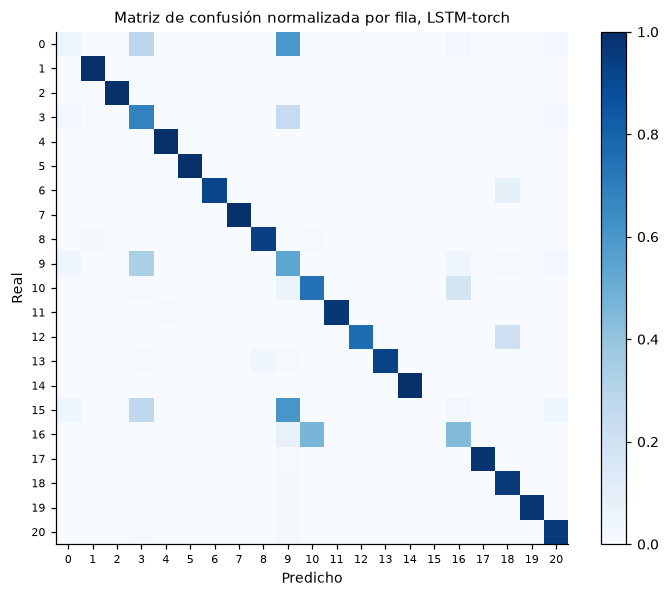

In [29]:
# F1 por clase y macro-F1 sobre TODA la prueba (regla 5): la precisión ve los errores de las demás clases.
prec, rec, f1s, soporte = precision_recall_fscore_support(y_te_w, y_pred, labels=clases, zero_division=0)
por_clase = pd.DataFrame({"faultNumber": clases, "precision": prec, "recall": rec, "f1": f1s, "support": soporte})
macro = f1_score(y_te_w, y_pred, labels=clases, average="macro", zero_division=0)
es_dificil = np.isin(clases, DIFICILES)
print(f"macro-F1 ({len(clases)} clases, sobre toda la prueba): {macro:.3f}")
print(f"media del F1 sin 3, 9 y 15 (incluye la clase normal): {f1s[~es_dificil].mean():.3f} | "
      f"solo 3, 9 y 15: {f1s[es_dificil].mean():.3f} | clase normal: {f1s[clases == 0][0]:.3f}")
display(por_clase.set_index("faultNumber").T.round(3))

cm = confusion_matrix(y_te_w, y_pred, labels=clases, normalize="true")
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(clases))); ax.set_yticks(range(len(clases)))
ax.set_xticklabels(clases, fontsize=7); ax.set_yticklabels(clases, fontsize=7)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real"); ax.grid(False)
ax.set_title(f"Matriz de confusión normalizada por fila, {METODO_DIAG}")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

In [30]:
# Recall por (fallo, simulación): la unidad del formato común (regla 11).
por_sim = (pd.DataFrame({"faultNumber": y_te_w, "simulationRun": s_te_w, "acierto": y_pred == y_te_w})
           .groupby(["faultNumber", "simulationRun"])["acierto"]
           .agg(recall="mean", n_ventanas="size").reset_index())
print("Recall por simulación, resumido por clase (count = simulaciones):")
por_sim.groupby("faultNumber")["recall"].agg(["count", "mean", "std", "min", "max"]).T.round(3)

Recall por simulación, resumido por clase (count = simulaciones):


faultNumber,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
count,10.000,10.000,10.000,10.000,10.000,10.000,10.000,10.0,10.000,10.000,10.000,10.000,10.000,10.000,10.0,10.000,10.000,10.000,10.000,10.000,10.000
mean,0.050,0.999,0.999,0.680,0.999,0.999,0.915,1.0,0.936,0.538,0.743,0.969,0.762,0.923,1.0,0.002,0.444,0.977,0.964,0.973,0.964
std,0.013,0.003,0.002,0.043,0.002,0.003,0.160,0.0,0.043,0.035,0.113,0.014,0.272,0.040,0.0,0.003,0.041,0.022,0.022,0.015,0.023
min,0.032,0.994,0.994,0.637,0.994,0.994,0.522,1.0,0.873,0.503,0.573,0.936,0.312,0.866,1.0,0.000,0.363,0.936,0.911,0.943,0.924
max,0.074,1.000,1.000,0.752,1.000,1.000,1.000,1.0,1.000,0.611,0.885,0.987,0.987,0.968,1.0,0.006,0.510,1.000,1.000,0.994,0.994


### Cómo leerlo

- **El macro-F1** da el mismo peso a cada clase; el F1 por clase dice dónde falla. Lee siempre la precisión junto al recall.
- **Las clases 0, 3, 9 y 15.** Son casi indistinguibles: en Rieth, las trayectorias de 3, 9 y 15 siguen pegadas a su gemela normal después del inicio (DAT-1). Si una de ellas tiene un recall alto, mira su precisión: lo más probable es que esté absorbiendo ventanas de las otras tres. En la matriz de confusión se ve como un bloque. Es justo lo que el «F1» del defecto B3 esconde, porque, calculado solo con las muestras de la clase, ignora esas ventanas ajenas; compruébalo en el *Verifícalo tú*.
- **El recall por simulación.** La última tabla da, por clase, cuántas simulaciones hay, su media, su desviación y sus extremos. Esa dispersión es la incertidumbre que el clásico no puede dar (allí hay una sola simulación por clase).
- **Lo que esto NO es:** una LSTM de verdad. Pocas épocas, ventana corta, sin ajuste de hiperparámetros y la mitad de las simulaciones de desarrollo. Es la tubería correcta con un modelo de juguete; el modelo bueno es tuyo (*Te toca*). Recuerda además que las primeras W − 1 muestras con fallo de cada simulación no se evalúan, porque una ventana necesita historia completa.

### Verifícalo tú

1. Calcula el «F1» defectuoso de una clase difícil, restringido a sus propias ventanas como en el CSV del cuaderno 02, y comprueba que coincide con 2r/(1+r) y no con el F1 de la tabla. **No lo copies nunca a un resultado.**
2. En Rieth, construye una clave `simulationRun * 1000 + sample` sin convertir a `int64` y cuenta cuántas claves distintas salen frente a las filas que hay (pista: carga las simulaciones 1 y 66).

In [31]:
# Verifícalo tú (1): el «F1» restringido a una clase es 2r/(1+r) (defecto B3).
# Solución (quita los '# ' de las líneas de abajo y ejecuta):
# c = DIFICILES[0]
# m = y_te_w == c
# f1_mal = f1_score(y_te_w[m], y_pred[m], labels=[c], average="macro", zero_division=0)   # ¡NO HAGAS ESTO!
# r = por_clase.set_index("faultNumber").loc[c, "recall"]
# print(f"'F1' restringido a la clase {c}: {f1_mal:.3f} | 2r/(1+r) = {2 * r / (1 + r):.3f}")
# print(f"F1 correcto de la clase {c}, sobre toda la prueba: {por_clase.set_index('faultNumber').loc[c, 'f1']:.3f}")

In [32]:
# Verifícalo tú (2): los ids de Rieth vienen en int16 y la aritmética con ellos se desborda (DAT-5).
# Solución (quita los '# ' de las líneas de abajo y ejecuta):
# if HAY_RIETH:
#     d = data.load_rieth(1, "test", runs=[1, 66], root=RIETH_DIR)
#     clave16 = d["simulationRun"] * 1000 + d["sample"]                                  # int16: se desborda
#     clave64 = d["simulationRun"].astype("int64") * 1000 + d["sample"].astype("int64")
#     print(d["simulationRun"].dtype, "| filas:", len(d), "| claves int16:", clave16.nunique(),
#           "| claves int64:", clave64.nunique())

## 8. Formato común de resultados → `results/raw/`

Regla 11: una fila por (`method`, `faultNumber`, `simulationRun`). Esto es una prueba de humo, así que va a `results/raw/` (ignorado por git) y no a `results/summary/`. Junto a los CSV se guarda `C00_configuracion.json` con la configuración, los ids usados y las versiones de las librerías (hallazgo I7 de la revisión: sin eso no se sabe con qué se generó una cifra).

In [33]:
SALIDA = Path("results/raw")
SALIDA.mkdir(parents=True, exist_ok=True)
CLAVE = ["method", "faultNumber", "simulationRun"]
escritos = {}

def guardar(df, nombre, clave=CLAVE):
    if clave is not None:
        assert not df.duplicated(clave).any(), f"{nombre}: filas repetidas para {clave}"
    ruta = SALIDA / nombre
    df.to_csv(ruta, index=False)
    escritos[str(ruta)] = len(df)

umbrales_clasico = {METODO_AE: umbral_ae, "PCA-SPE": pca.spe_limit_}
guardar(res_clasico.assign(fuente="classic", nivel_confianza=NIVEL, k=K, calibracion="reservada",
                           umbral=res_clasico["method"].map(umbrales_clasico)),
        "C00_deteccion_clasico.csv")
guardar(trampas.reset_index().assign(fuente="classic", nivel_confianza=NIVEL), "C00_trampas_clasico.csv", clave=None)

if HAY_RIETH:
    umbrales_R = {METODO_AE: umbral_R, f"{METODO_AE}|umbral-en-muestra": umbral_R_en_muestra,
                  "PCA-SPE": pca_R.spe_limit_, "PCA-SPE|umbral-en-muestra": pca_R_en_muestra.spe_limit_}
    guardar(res_R.assign(fuente="rieth", nivel_confianza=NIVEL, k=K,
                         calibracion=np.where(res_R["method"].str.endswith("umbral-en-muestra"), "en_muestra", "reservada"),
                         umbral=res_R["method"].map(umbrales_R)),
            "C00_deteccion_rieth.csv")

guardar(por_sim.assign(method=METODO_DIAG, fuente=FUENTE_DIAG, ventana=W, paso=PASO)
        [["method", "faultNumber", "simulationRun", "recall", "n_ventanas", "fuente", "ventana", "paso"]],
        "C00_diagnostico_por_simulacion.csv")
guardar(por_clase.assign(method=METODO_DIAG, fuente=FUENTE_DIAG, macro_f1=macro, ventana=W, paso=PASO),
        "C00_diagnostico_por_clase.csv", clave=["method", "faultNumber"])

import scipy, sklearn
configuracion = {
    "cuaderno": "C00_punto_de_partida_deeplearning.ipynb",
    "fecha": time.strftime("%Y-%m-%d %H:%M"),
    "python_ejecutable": sys.executable,
    "versiones": {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
                  "scipy": scipy.__version__, "scikit-learn": sklearn.__version__,
                  "torch": torch.__version__ if USAR_TORCH else None, "tfmfdd": tfmfdd.__version__},
    "protocolo_yaml": cfg,
    "alpha_contrastes": ALPHA_CONTRASTES,
    "camino": "torch" if USAR_TORCH else "sklearn",
    "hilos_torch": torch.get_num_threads() if USAR_TORCH else None,   # con otro número de hilos, las cifras cambian algo
    "metodo_ae": METODO_AE, "hp_ae": HP_AE, "metodo_diag": METODO_DIAG, "hp_diag": HP_DIAG,
    "ventana": W, "paso": PASO, "fuente_diagnostico": FUENTE_DIAG,
    "clasico": {"n_tr": len(Z_tr), "n_es": len(Z_es), "n_cal": len(Z_cal)},
    "rieth": None if not HAY_RIETH else {
        "origen": ORIGEN_RIETH, "hp_ae": HP_AE_R, "ids_fit": ids_fit, "ids_es": ids_es, "ids_cal": ids_cal,
        "ids_prueba": ids_prueba, "ids_diag_tr": ids_d_tr, "ids_diag_va": ids_d_va, "ids_diag_te": ids_d_te},
}
(SALIDA / "C00_configuracion.json").write_text(json.dumps(configuracion, indent=2, ensure_ascii=False, default=str),
                                               encoding="utf-8")
escritos[str(SALIDA / "C00_configuracion.json")] = None
for ruta, filas_escritas in escritos.items():
    print(ruta, "" if filas_escritas is None else f"({filas_escritas} filas)")

results\raw\C00_deteccion_clasico.csv (44 filas)
results\raw\C00_trampas_clasico.csv (8 filas)
results\raw\C00_deteccion_rieth.csv (1680 filas)
results\raw\C00_diagnostico_por_simulacion.csv (210 filas)
results\raw\C00_diagnostico_por_clase.csv (21 filas)
results\raw\C00_configuracion.json 


## 9. Lyu et al. (2026): qué hay que replicar y qué queda por verificar

**Referencia.** Lyu, N., Botcha, S., Kulkarni, E., Pagaria, S., Alves, V., Sunshine, E. M. y Kitchin, J. R. (2026). *Benchmarking Machine Learning Fault Detection Methods on the Tennessee Eastman Process Dataset*. ChemRxiv, v1 del 27 de enero de 2026, preprint no revisado por pares. https://doi.org/10.26434/chemrxiv.10001628/v1

Todo lo que sigue sale del PDF de la carpeta de contexto (`04_Investigacion/`). Las páginas son las **del manuscrito**, el número al pie; en el visor de PDF súmale 1, porque la primera página es la portada de ChemRxiv.

**Qué hicieron con los autoencoders (lo que hay que replicar).**
- Dos arquitecturas entrenadas solo con operación normal: un autoencoder LSTM (LSTM-AE) y uno convolucional 1D (Conv-AE) (pp. 11-12).
- Datos de Rieth; estandarización con media y varianza calculadas solo con el entrenamiento (p. 7); ventanas deslizantes de paso 1, generadas dentro de cada simulación y etiquetadas con la última muestra (p. 8).
- Partición para la detección: 100 simulaciones normales de entrenamiento y 50 de validación; prueba binaria con 120 simulaciones normales y 50 con fallo por cada tipo de fallo, en total 970 simulaciones y 795 200 muestras; el fallo entra en la muestra 161 (pp. 8-9).
- Hiperparámetros finales en la Tabla 4 (p. 15): el LSTM-AE usa ventanas de 38 muestras y el percentil de umbral 97,95; el Conv-AE, ventanas de 40 y el percentil 98,65 (el resto, en la tabla). Se ajustaron con Optuna, con 50 ensayos que maximizan el F1 ponderado en validación y parada temprana de paciencia 5 (p. 9).
- El umbral es un percentil del error de reconstrucción sobre la distribución de entrenamiento (p. 11), con el percentil que salió de ese ajuste (p. 17).
- Excluyen los fallos 3, 9 y 15 (pp. 6 y 8). Reportan exactitud, precisión, recall, F1, y las áreas bajo las curvas ROC y de precisión-recall (ROC-AUC y PR-AUC) (pp. 9-10); no reportan retardo ni hacen contrastes.
- En su prueba (Tabla 6, p. 19), el Conv-AE da un 99,39 % de exactitud y F1 de 0,9964, y el LSTM-AE, un 96,96 % y 0,9820.
- En un conjunto independiente generado con otras semillas, evaluado **sin recalibrar el umbral** (p. 13), el Conv-AE cae al 76,04 % y el LSTM-AE al 93,93 % (Tabla 11, p. 26). El Conv-AE conserva un recall del 100 % y un ROC-AUC de 0,981: el fallo son falsas alarmas, y los autores lo atribuyen a la calibración del umbral (p. 27).
- Código, datos preprocesados y pesos entrenados están en https://github.com/KitchinHUB/tep-manuscript, con cuadernos por etapas: serie 01 (creación del conjunto), 10 (ajuste de hiperparámetros), 20 (entrenamiento y evaluación), 30 (filtro con un modelo oculto de Markov, HMM, *hidden Markov model*) y 40 (generalización) (p. 32).

**Por qué encaja con tu OE3.** Su caída toca el mismo componente que la trampa (a) de la sección 5: el umbral. Lo fijan sobre el error de entrenamiento y no lo recalibran en datos de otras semillas; el ordenamiento aguanta (ROC-AUC alto) y el umbral no. Con su diseño no se puede separar cuánto es sesgo de calibrar en muestra y cuánto es cambio de distribución entre sus dos conjuntos de datos. Esa separación es justo lo que puedes medir con el protocolo: umbral con normales reservados, FAR y FDR por simulación, retardo, 3, 9 y 15 aparte y contrastes pareados, cambiando un componente cada vez.

**Qué queda por verificar** (en sus cuadernos, no en el PDF):
- [VERIFICAR] **El 87,57 % del traspaso.** En el PDF, 87,57 % es la exactitud de TransKal, un clasificador multiclase, en el conjunto independiente (Tabla 10, p. 25). No es de un autoencoder: para el OE3, las cifras que cuentan son las de las Tablas 6 y 11.
- [VERIFICAR] **Las corridas por partición.** El PDF da las de arriba para la detección y 100, 50 y 200 simulaciones por clase para el diagnóstico (p. 8). El informe del estado del arte daba otras cifras, sacadas de fragmentos: usa las del PDF y confírmalas con los ids de sus cuadernos 01.
- [VERIFICAR] **¿La validación de los autoencoders tenía fallos?** El texto dice que la validación semisupervisada es solo de operación normal (p. 8), pero la Tabla 2 (p. 14) da un «Best Val F1» para los dos autoencoders, y un F1 necesita muestras con fallo. Si la validación tenía fallos, el percentil del umbral se eligió con etiquetas de fallo (una forma suave de la trampa b) y el método no es semisupervisado en sentido estricto. Se resuelve en sus cuadernos 10.
- [VERIFICAR] **¿Comparten ids las simulaciones normales y las de fallo de su prueba binaria?** En Rieth, la simulación normal r y la de fallo r comparten semilla (DAT-1): si su prueba usa los mismos ids para las dos, las muestras previas al fallo están duplicadas.
- [VERIFICAR] **La composición de la prueba binaria.** Cuenta propia, no del PDF: 120 × 960 + 850 × 800 = 795 200, que cuadra con simulaciones normales enteras y solo el tramo con fallo de las demás. Es una inferencia hasta verlo en su código.
- [VERIFICAR] Si el conjunto independiente (generado con `tep-sim`, p. 13) está en el repositorio o hay que regenerarlo.

## 10. Te toca

Esto es tu contribución y no está resuelto a propósito. Cada celda `TODO` se ejecuta sin error tal como está (no hace nada hasta que la rellenes) y reutiliza las funciones de arriba, para que tu modelo entre en la misma tubería de medida que el PCA-SPE. Hazlo en tu propio repositorio, importando `tfmfdd`; los cuadernos del repositorio de Pablo son ejemplos.

Orden recomendado: primero la réplica de Lyu (TODO 3), porque sin reproducir sus cifras con su protocolo no hay punto de partida para atribuir nada; después tu autoencoder (TODO 1) y la red recurrente (TODO 2), y al final la atribución (TODO 4).

In [34]:
# TODO 1 · Tu autoencoder profundo en PyTorch (detección).
# Qué: más capas, regularización (dropout) y, si quieres, ventanas temporales
#      (un LSTM-AE o un Conv-AE como los de Lyu et al., Tabla 4, p. 15).
# Cómo, sin salirte del protocolo:
#   1. Entrena con Z_tr (clásico) o ZR_tr (Rieth); parada temprana con Z_es / ZR_es. Nunca con la prueba.
#   2. Umbral con limits.limit_empirical (o limit_kde) sobre Z_cal / ZR_cal, al nivel NIVEL del yaml.
#   3. Evalúa con evaluar_en_clasico(...) y, en Rieth, con el mismo bucle de la sección 6.
#   4. Guarda en results/raw/ con el formato común y la configuración.
# Si sale mucho mejor que el PCA-SPE, antes de celebrar revisa de dónde sale el umbral.
mi_puntuar = None     # función X -> estadístico por muestra (por ejemplo, tu error de reconstrucción)
mi_umbral = None      # calibrado con normales reservados
if mi_puntuar is not None and mi_umbral is not None:
    res_mio, _ = evaluar_en_clasico(mi_puntuar, mi_umbral, "mi-autoencoder")
    res_mio["retardo_interpretable"] = retardo_interpretable(res_mio)
    display(resumen_deteccion(pd.concat([res_clasico, res_mio], ignore_index=True)).round(3))

In [35]:
# TODO 2 · La red recurrente de verdad (diagnóstico).
# Punto de partida: ventanas_por_trayectoria y entrenar_diagnostico de la sección 7.
#   - Ventana: Lyu et al. buscan entre 20 y 40 muestras y se quedan con 38-40 (p. 8 y Tabla 3, p. 15).
#   - Más simulaciones: datos.runs_finales del yaml cuando el código esté estable (vigila la memoria).
#   - Más épocas, más capas o una CNN 1D; ajusta hiperparámetros con la validación, nunca con la prueba.
#   - Reporta el macro-F1 y el F1 por clase sobre TODA la prueba, con 0, 3, 9 y 15 aparte,
#     y el recall por (fallo, simulación) en el formato común.
#   - Compara con el Random Forest de Jonathan sobre las mismas simulaciones (stats.compare_methods).
W_MIA = None          # por ejemplo 40
HP_MIA = None         # por ejemplo {"oculta": 64, "lr": 1e-3, "lote": 128, "epocas_max": 50, "paciencia": 5}
if W_MIA is not None and HP_MIA is not None:
    pass              # construye ventanas con W_MIA, entrena con HP_MIA y mide como en la sección 7

In [36]:
# TODO 3 · Réplica de Lyu et al. (2026): primero reproducir, después modificar.
#   1. Clona https://github.com/KitchinHUB/tep-manuscript (p. 32) y apunta LYU_REPO a esa carpeta.
#   2. De sus cuadernos 01 saca los ids exactos de cada partición y guárdalos en tu repositorio.
#   3. Entrena sus dos autoencoders con los hiperparámetros de la Tabla 4 (p. 15) y reproduce la Tabla 6
#      (p. 19) con SU protocolo. Si no sale, no sigas: primero entiende por qué.
#   4. Resuelve los [VERIFICAR] de la sección 9 leyendo sus cuadernos 10 y 20.
LYU_REPO = None       # por ejemplo Path.home() / "repos" / "tep-manuscript"
if LYU_REPO is not None and Path(LYU_REPO).exists():
    for cuaderno_lyu in sorted(Path(LYU_REPO).rglob("*.ipynb")):
        print(cuaderno_lyu.relative_to(LYU_REPO))

In [37]:
# TODO 4 · Atribución por componentes: de su protocolo al nuestro, cambiando UNO cada vez.
# La columna 'efecto' se rellena desde tus CSV (con signo e intervalo), nunca a mano.
# El orden importa: si dos componentes interactúan, el efecto de cada uno depende de cuál va antes.
# Declara el orden antes de medir. La partición por simulación y el escalado solo con entrenamiento
# ya los hacen ellos, así que no son brazos de esta tabla.
brazos = pd.DataFrame([
    {"paso": 0, "componente": "réplica", "cambio": "su protocolo tal cual (reproduce sus Tablas 6 y 11)"},
    {"paso": 1, "componente": "umbral", "cambio": "percentil del error de entrenamiento -> normales reservados"},
    {"paso": 2, "componente": "elección del percentil", "cambio": "F1 en validación -> nivel fijo del yaml"},
    {"paso": 3, "componente": "fallos", "cambio": "17 fallos -> 20, con 3, 9 y 15 aparte"},
    {"paso": 4, "componente": "métrica", "cambio": "exactitud por muestra -> FAR, FDR y retardo por simulación"},
    {"paso": 5, "componente": "contraste", "cambio": "una cifra -> Wilcoxon pareado con Holm frente al PCA-SPE"},
])
brazos["efecto"] = np.nan     # TODO: sale de tus CSV en results/raw/
brazos

,paso,componente,cambio,efecto
0,0,réplica,su protocolo tal cual (reproduce sus Tablas 6 ...,NaN
1,1,umbral,percentil del error de entrenamiento -> normal...,NaN
2,2,elección del percentil,F1 en validación -> nivel fijo del yaml,NaN
3,3,fallos,"17 fallos -> 20, con 3, 9 y 15 aparte",NaN
4,4,métrica,"exactitud por muestra -> FAR, FDR y retardo po...",NaN
5,5,contraste,una cifra -> Wilcoxon pareado con Holm frente ...,NaN


## 11. Dónde está cada cosa

| Lo que hicimos | Dónde | Función |
|---|---|---|
| Leer el protocolo | `configs/baseline.yaml` | `yaml.safe_load` |
| Cargar el clásico | `data.py` | `load_classic`, `values`, `FAULT_ONSET_TEST`, `fault_onset` |
| Cargar Rieth | `data.py` | `load_rieth(fallo, split, runs=[...], root=RIETH_DIR)` |
| Partir por simulación | `data.py` | `split_runs` |
| Estandarizar sin fuga | `preprocessing.py` | `Scaler` |
| Ventanas que no cruzan trayectorias | este cuaderno, con la idea de `preprocessing.lag_by_run` | `ventanas_por_trayectoria` |
| PCA-SPE de referencia | `pca.py` | `PCAMonitor(...).fit(X_fit, X_cal=X_cal)` |
| Umbral del autoencoder | `limits.py` | `limit_empirical`, `limit_kde` |
| FAR, FDR y retardo | `metrics.py` | `evaluate_run`, `far`, `fdr`, `HARD_FAULTS` |
| Medias e intervalos por simulación | `metrics.py` | `aggregate` |
| Contrastes pareados | `stats.py` | `compare_methods`, `paired_test` |
| F1 por clase y macro-F1 | scikit-learn | `precision_recall_fscore_support`, `f1_score(..., average="macro")`, `confusion_matrix` |
| Figuras | `plots.py` | `use_style`, `control_chart`, `fdr_by_fault`, `COLORS` |
| Autoencoder y red de diagnóstico | PyTorch o scikit-learn (este cuaderno) | `entrenar_autoencoder`, `error_reconstruccion`, `entrenar_diagnostico` |
| Evaluación reutilizable | este cuaderno | `evaluar_en_clasico`, `retardo_interpretable`, `resumen_deteccion`, `umbral_que_maximiza_f1` |

## 12. Qué cambia con la v0.3

Defectos conocidos del paquete (revisión del 27/09, `docs/revision_2026-09-27.md`) que este cuaderno esquiva, y cómo:

- **B2. Inicio del fallo en el entrenamiento clásico.** `data.FAULT_ONSET_TRAIN_CLASSIC` vale 20 y es falso: en los `dXX.dat` el fallo está activo desde la fila 0. Aquí no se usa la constante: se usa `data.fault_onset("train", "classic")`, que devuelve `None`, y los ficheros de entrenamiento enteros. La revisión propone eliminarla o dejarla en 0 con una prueba que lea los datos.
- **B3. F1 por clase.** El CSV de diagnóstico del cuaderno 02 calcula el «F1» con solo las muestras de cada clase, y eso da 2r/(1+r). Aquí se calcula con `precision_recall_fscore_support` sobre toda la prueba. La revisión propone una prueba con una matriz de confusión conocida.
- **I1. `metrics.summary`.** Promedia retardos marcados como `detected_at_chance` y llama «nunca detectados» a los fallos sin racha, aunque su FDR sea del orden de la FAR. Aquí el resumen es manual (`resumen_deteccion`, `retardo_interpretable`) y `summary` no se usa. La revisión propone que la v0.3 excluya esos retardos y renombre las columnas.
- **I2. Contrastes.** `compare_methods` hace todos contra todos con Holm por fallo, no tiene parámetro de baseline, su `effect_size` pierde el signo y el alfa 0,05 solo existe como valor por defecto de `holm_correction`. Aquí se comparan solo dos métodos (un par por fallo), se reporta `median_difference`, no se usa `effect_size` y `ALPHA_CONTRASTES` se declara al principio. La revisión propone para la v0.3 un parámetro `baseline=`, el intervalo de la diferencia, `r` con signo y el alfa de contraste en el yaml.
- **I8. Umbral de `detected_at_chance`.** El 0,10 se motivó mirando los ficheros de prueba del clásico. Aquí se usa tal cual; en Rieth hay que declararlo antes de ejecutar y analizar la sensibilidad con 0,05 y 0,15.
- **M3 y M4. Semillas y constantes a mano.** El cuaderno 03 fijaba 0,7, 0,99 y `random_state=0`. Aquí todo sale del yaml y las semillas de PyTorch y scikit-learn son `protocolo.semilla`.
- **I7 y M1. Versiones.** No había registro de con qué versiones se generó cada salida, y `tfmfdd.__version__` sigue diciendo 0.1.0. Aquí `C00_configuracion.json` guarda las versiones; la revisión propone subir la versión en la v0.3 y añadir un `requirements-lock.txt`.
- **DAT-5 y DAT-6. Rieth.** `load_rieth` devuelve los ids en `int16` e ignora sin aviso los ids que no existen. Aquí se convierten a `int64` y se comprueba `nunique()`. Además, `load_rieth` lee el fichero entero antes de filtrar las simulaciones (hay un pico de memoria transitorio en cada llamada), así que las cargas van de una en una y lo que ya no hace falta se libera con `del`.
- **B1. Instalación.** Hoy no hay etiqueta que sirva: `v0.2` no está en GitHub y `v0.1` instala el paquete del 17/09 (sin `convert_rieth` y con el `compare_methods` antiguo). Con la v0.3 será `python -m pip install "tfmfdd @ git+https://github.com/pabdus/tfm-fdd-core@v0.3"`, y en tu `requirements.txt` irá esa misma línea, nunca `@main`.
- **REP-4. El protocolo no viaja con el paquete.** `configs/baseline.yaml` no va dentro de `tfmfdd`: en tu repositorio necesitas una copia de la misma versión, y los valores por defecto de `PCAMonitor` (`variance`, calibración sin `X_cal`) no son los del protocolo. Aquí todo se pasa desde el yaml y `X_cal` va siempre explícito.
- **DAT-1, matiz.** El inicio nominal de Rieth no siempre es el efectivo: la sección 6 lo mide y las filas afectadas se declaran como ruido de etiqueta hasta que `decisiones.md` diga otra cosa.
- **El cuaderno 03**, la versión anterior de este, entrena sin parada temprana, fija a mano la semilla y las fracciones, enseña retardos sin marcar los que no se interpretan y no llega a Rieth ni al diagnóstico. Este cuaderno lo sustituye como punto de partida del bloque C.

In [38]:
print(f"Tiempo total de ejecución: {(time.time() - T_INICIO) / 60:.1f} minutos | camino "
      f"{'PyTorch' if USAR_TORCH else 'scikit-learn'} | Rieth: {'sí' if HAY_RIETH else 'no'}")

Tiempo total de ejecución: 1.7 minutos | camino PyTorch | Rieth: sí
